In [5]:
from MFDFA_functions import get_moment_fluctuations_q, get_generalised_hurst, get_mf_spectrum
import numpy as np
from scipy.stats import norm, kurtosis, combine_pvalues
from scipy.stats import t as studt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from MFDFA_new import MFDFA
import pandas as pd

In [6]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")

In [ ]:
euro_d.set_index("Date", inplace=True)
sgd_d.set_index("Date", inplace=True)

euro_d.rename(columns = {
    "Spot": "Mid"
}, inplace = True)
sgd_d.rename(columns = {
    "Spot": "Mid"
}, inplace = True)

Use 3 months of 5 second data to start.

In [7]:
length_s5 = len(euro_s5)
euro_s5 = euro_s5.iloc[int(length_s5/2):]
sgd_s5 = sgd_s5.iloc[int(length_s5/2):]

Get log returns.

In [8]:
def get_log_returns(df):

    df['Log_r'] = np.log(pd.to_numeric(df['Mid'])).diff()
    df = df.dropna()
    return df

In [9]:
euro_s5 = get_log_returns(euro_s5)
sgd_s5 = get_log_returns(sgd_s5)
euro_d = get_log_returns(euro_d)
sgd_d = get_log_returns(sgd_d)

We need to do fat tail, vol clustering, long memory tests to compare with simulations.

In [11]:
def compute_acf(x, lags):
    x_mean = x.mean()
    y = x - x_mean

    acf_vals = np.zeros(lags)
    acf_vals[0] = 1.0
    for i in range(1, lags):

        acf_vals[i] = (np.dot(y[i:], y[:-i])) / np.dot(y, y)

    return acf_vals

def get_confd_bands(n_obs, acfs, alpha = 0.05):
    '''
    Assuming underlying process is MA(q) we use this.
    '''


    K = len(acfs)
    z = norm.ppf(1 - alpha/2)
    lower = np.zeros(K)
    upper = np.zeros(K)

    for h in range(1, K):
        var_h = (1 + 2*np.sum(acfs[1:h]**2)) / n_obs
        halfwidth = z * np.sqrt(var_h)
        lower[h] = -halfwidth
        upper[h] =  halfwidth

    return lower, upper

In [8]:
def plot_acf(r, type, detrend = False):

    if not detrend:
        x = abs(r["Log_r"])
    else:
        x = abs(r["Log_r_detrended"])

    n_obs = len(x)

    if n_obs < 10_000: # daily
        lags = 2000
    else:
        lags = 10**5 #S5


    acf_vals = compute_acf(x, lags)
    lo, up = get_confd_bands(n_obs, acf_vals)

    other = 1.96 / np.sqrt(n_obs)

    plt.figure(figsize=(10, 5))
    plt.stem(range(0, lags), acf_vals[0:], linefmt='b-', markerfmt='bo', basefmt=' ')
    plt.plot(up[1:], '-',color = 'orange', linewidth = 3,  label = "Bartlett 95% CI")
    plt.plot(lo[1:], "-", color = "orange", linewidth = 3)
    plt.axhline(y = other, color = "purple", linewidth = 3, label = "White noise 95% CI")
    plt.axhline(y = -other, color = "purple", linewidth = 3)
    plt.ylim([-0.5, 0.5])
    plt.xlabel('Lag', fontsize = 18)
    plt.ylabel('ACF', fontsize = 18)
    plt.title(f'Autocorrelation Function for {type} with Confidence Bands', fontsize = 18)
    plt.tight_layout()
    plt.legend(fontsize = 'large')
    plt.savefig(f"/Users/alexvillamartin/Documents/MSc Diss/Plots/ACF_{type}")
    plt.show()


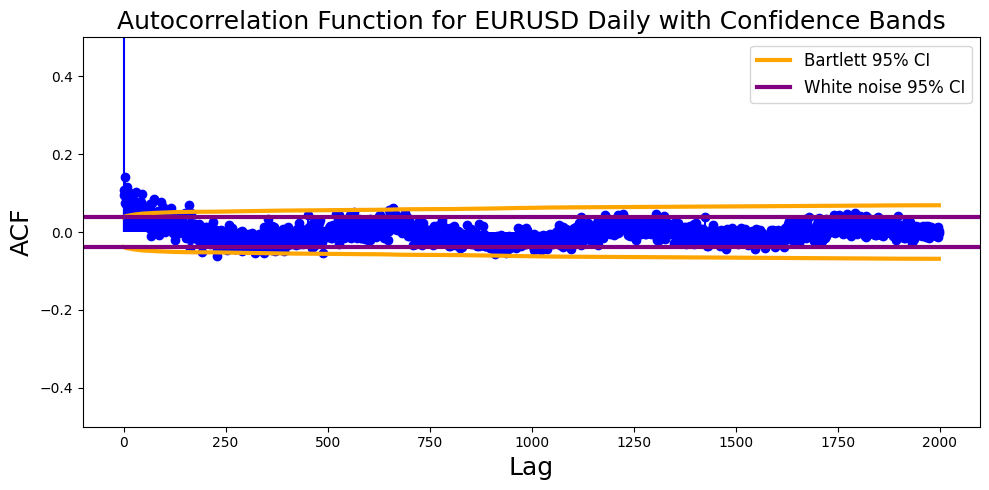

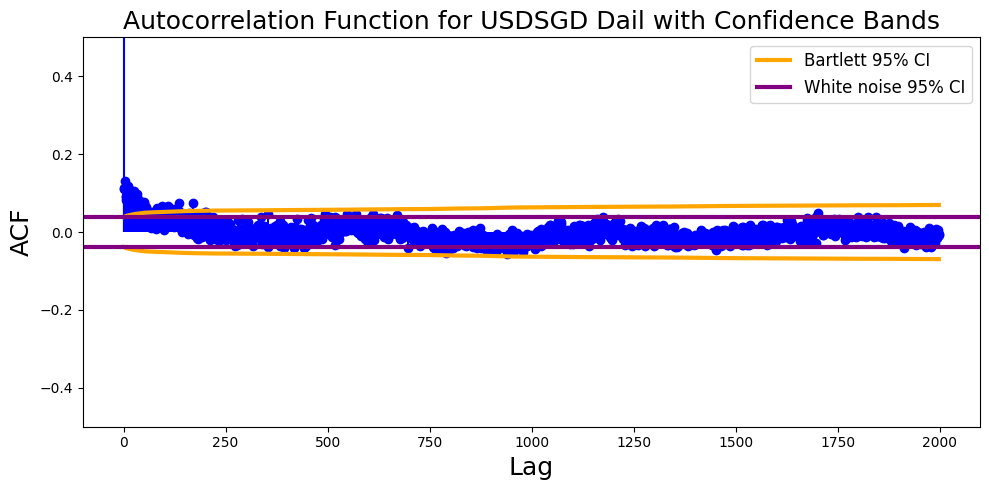

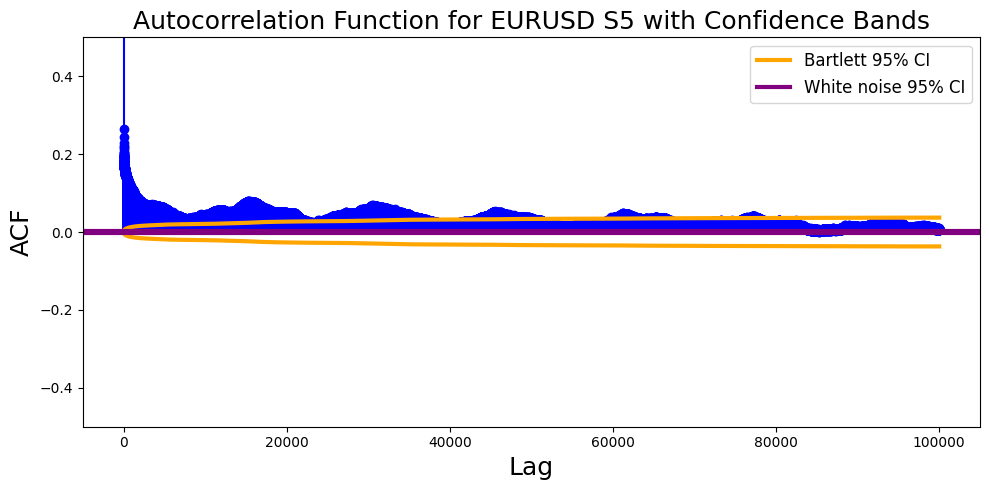

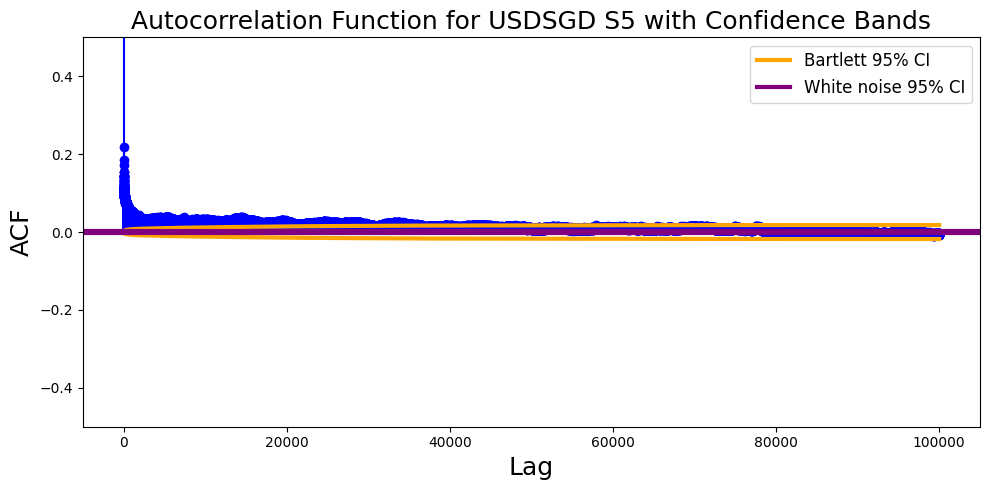

In [9]:
types = ["EURUSD Daily", "USDSGD Dail", "EURUSD S5", "USDSGD S5"]
datas = [euro_d, sgd_d, euro_s5, sgd_s5]

for i in range(len(types)):
    plot_acf(datas[i], types[i])

Humps in secondly plot likely to be from cyclic trends in secondly data over a day so consider removing this and doing again. 

For simplicty choose data between 08:00 to 17:00 and ffil missing values - review later for extensions.

In [10]:
def filter_trading_hours(df, start_hour=8, end_hour=17):

    df_copy = df.copy()
    
    mask = (df_copy.index.time >= pd.Timestamp(f'{start_hour:02d}:00:05').time()) & (df_copy.index.time <= pd.Timestamp(f'{end_hour:02d}:00:00').time())
    
    return df_copy[mask]

def remove_first_day_and_last(df):
    df_copy = df.copy()

    first_date = df_copy.index.date[0] 
    last_date = df_copy.index.date[-1]

    mask = (df_copy.index.date != first_date) & (df_copy.index.date != last_date)

    return df_copy[mask]

In [11]:
euro_s5_clean = remove_first_day_and_last(filter_trading_hours(euro_s5))
sgd_s5_clean = remove_first_day_and_last(filter_trading_hours(sgd_s5))

In [12]:
def check_complete_5s_intervals(df):
    '''
    This function overlays a full 5 second index onto data and ffils missing values to ensure all intervals in 
    specified hours are there. 
    '''

    df_copy = df.copy()
    
    start_date = df_copy.index.min().floor('D')
    end_date = df_copy.index.max().ceil('D')
    full_index = pd.date_range(start=start_date, end=end_date, freq='5s')
    
    trading_mask = (full_index.time >= pd.Timestamp('08:00:05').time()) & (full_index.time <= pd.Timestamp('17:00:00').time())
    weekday_mask = full_index.dayofweek < 5 

    trading_index = full_index[weekday_mask & trading_mask]
    
    df_complete = df_copy.reindex(trading_index).ffill()
    
    return df_complete

In [13]:
euro_s5_clean = check_complete_5s_intervals(euro_s5_clean)
sgd_s5_clean = check_complete_5s_intervals(sgd_s5_clean)

In [14]:
# do checks 
print("Euro S5 data info:")
print(f"Start: {euro_s5_clean.index.min()}")
print(f"End: {euro_s5_clean.index.max()}")
print(f"Total observations: {len(euro_s5_clean)}")
print(f"Expected 5 second intervals per day (9 hours): {9 * 60 * 60 / 5}")
print(f"Number of trading days: {len(pd.Series(euro_s5_clean.index.date).unique())}")
print(f"Expected total observations: {len(pd.Series(euro_s5_clean.index.date).unique()) * 9 * 60 * 60 / 5}")

print("\nSGD S5 data info:")
print(f"Start: {sgd_s5_clean.index.min()}")
print(f"End: {sgd_s5_clean.index.max()}")
print(f"Total observations: {len(sgd_s5_clean)}")
print(f"Number of trading days: {len(pd.Series(sgd_s5_clean.index.date).unique())}")

print(f"\nEuro missing values: {euro_s5_clean.isnull().sum().sum()}")
print(f"SGD missing values: {sgd_s5_clean.isnull().sum().sum()}")

Euro S5 data info:
Start: 2025-03-27 08:00:05+00:00
End: 2025-06-12 17:00:00+00:00
Total observations: 362880
Expected 5 second intervals per day (9 hours): 6480.0
Number of trading days: 56
Expected total observations: 362880.0

SGD S5 data info:
Start: 2025-03-27 08:00:05+00:00
End: 2025-06-12 17:00:00+00:00
Total observations: 362880
Number of trading days: 56

Euro missing values: 0
SGD missing values: 0


Do intraday pattern removing using logic in MF analysis lit survey paper. 

In [15]:
n_days = len(pd.Series(sgd_s5_clean.index.date).unique())
K = len(sgd_s5_clean) // n_days # number of points per day

Since some $\bar{Y}(k)$ are very small, according to lit we can subtract rather than divide. 

In [16]:
def get_trend(Y, K):

    n_days = len(Y) // K       

    trend = Y.reshape(n_days, K).mean(axis=0)

    return trend

def get_detrended_series(trend, Y, K, small = True):

    n_days = len(Y) // K

    if small:
        X = Y.reshape(n_days, K) - trend
    else:
        X = Y.reshape(n_days, K) / trend

    return X.ravel()


In [17]:
eur_s5_log_rs_clean = np.array(euro_s5_clean["Log_r"])
sgd_s5_log_rs_clean = np.array(sgd_s5_clean["Log_r"])

In [18]:
eur_trend = get_trend(eur_s5_log_rs_clean, K)
sgd_trend = get_trend(sgd_s5_log_rs_clean, K)
euro_s5_clean["Log_r_detrended"] = get_detrended_series(eur_trend, eur_s5_log_rs_clean, K)
sgd_s5_clean["Log_r_detrended"] = get_detrended_series(sgd_trend, sgd_s5_log_rs_clean, K)

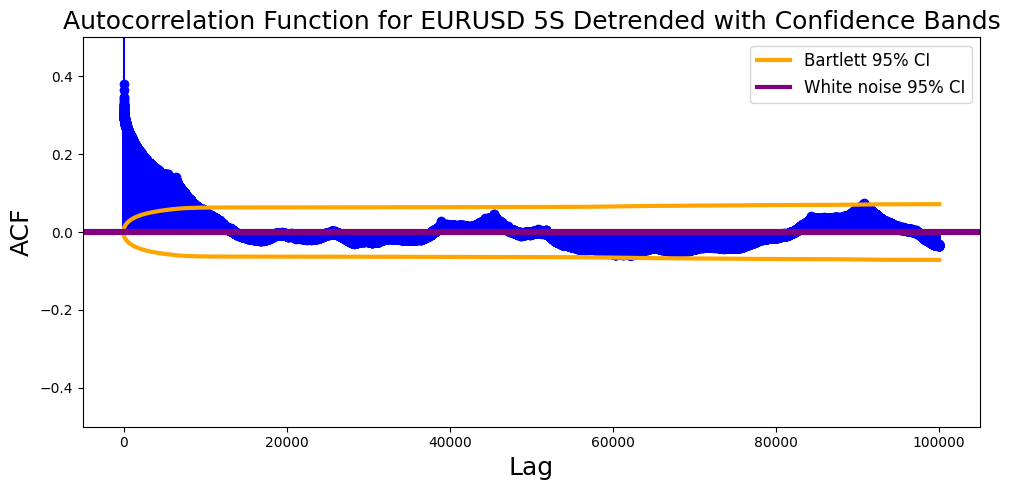

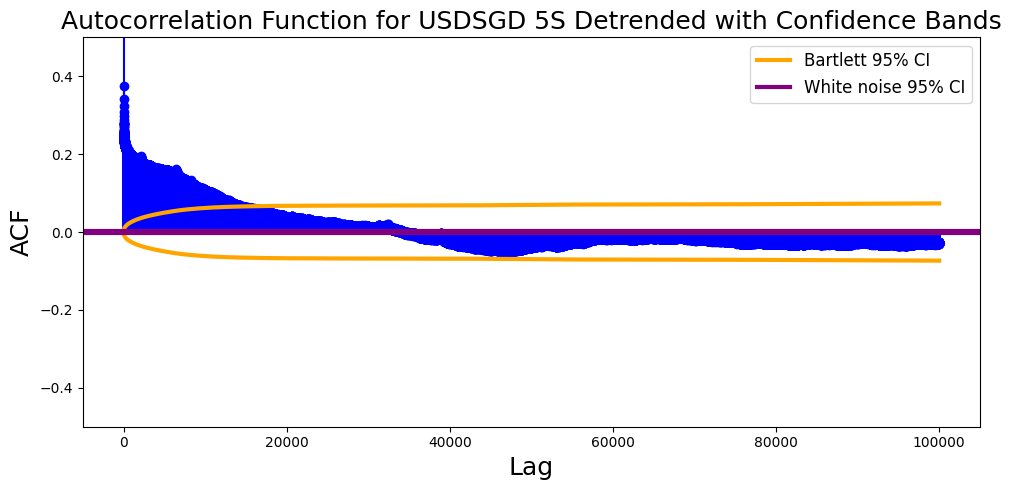

In [19]:
plot_acf(euro_s5_clean, type = "EURUSD 5S Detrended", detrend=True)
plot_acf(sgd_s5_clean, type = "USDSGD 5S Detrended", detrend=True)

For sake of remaining stylised facts just use clean timestamps with intraday trends removed. 

In [53]:
def get_qq_plot(r, type, detrend = True):

    if detrend:
        X = r["Log_r_detrended"]
    else: 
        X = r["Log_r"]

    stats.probplot(X, dist="norm", plot=plt)
    plt.title(f"QQ plot vs Normal for {type}")
    plt.xlabel("Theoretical quantiles")
    plt.ylabel("Sample quantiles")
    plt.tight_layout()
    plt.show()


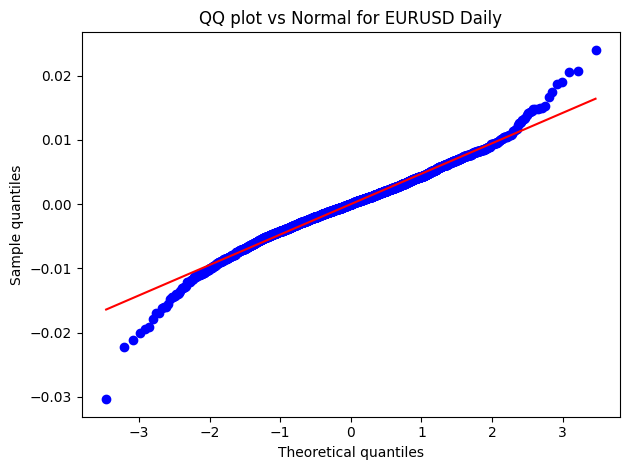

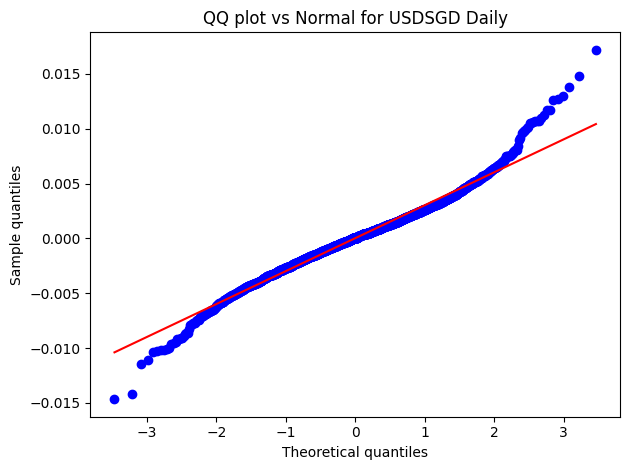

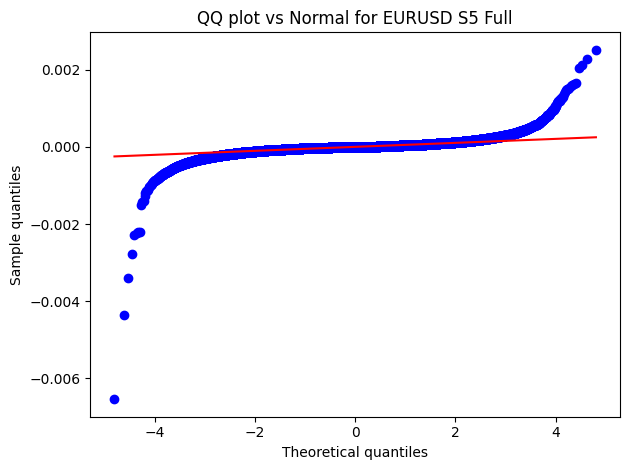

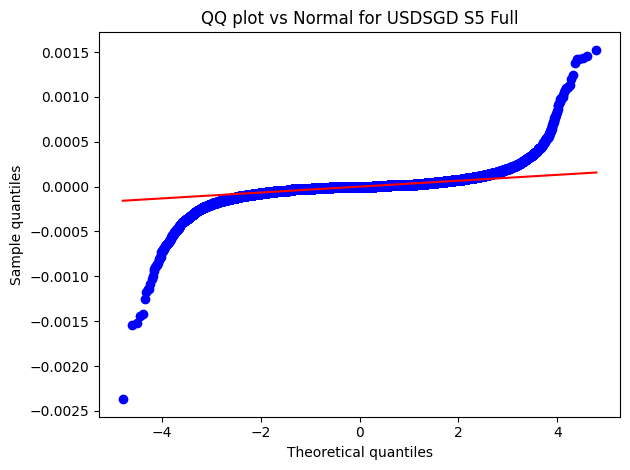

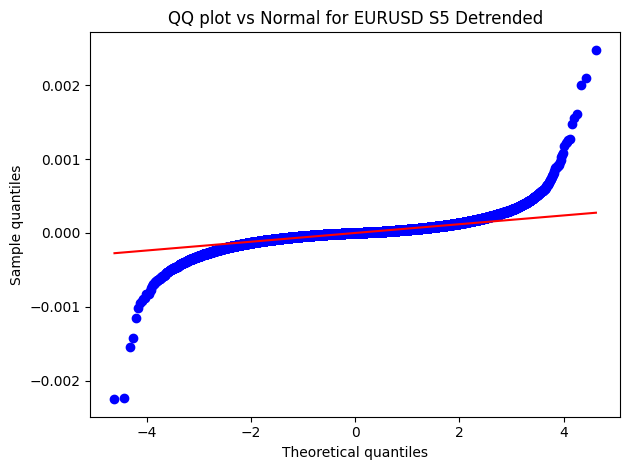

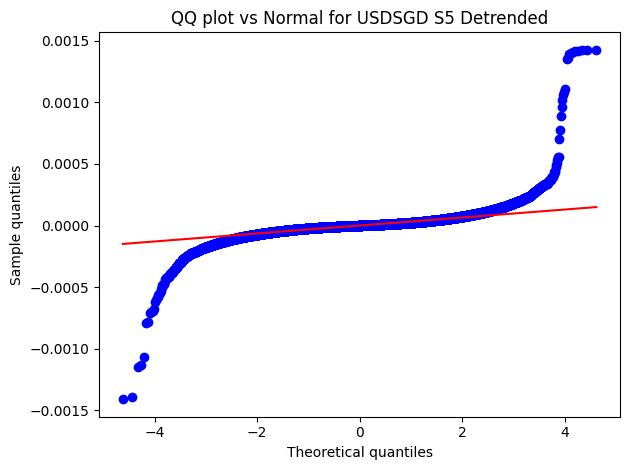

In [54]:
types = ["EURUSD Daily", "USDSGD Daily", "EURUSD S5 Full", "USDSGD S5 Full", "EURUSD S5 Detrended", "USDSGD S5 Detrended"]
datas = [euro_d, sgd_d, euro_s5, sgd_s5, euro_s5_clean, sgd_s5_clean]
detrend = [False, False, False, False, True, True]

for i in range(len(types)):
    get_qq_plot(datas[i], types[i], detrend=detrend[i])

The extra kurtosis is because of secondly data as we still observe it for full series and after editing time stamps and detrending. 

Quantify kurtosis.

In [55]:
Exkurtosis = [kurtosis(euro_d["Log_r"]), kurtosis(sgd_d["Log_r"]), kurtosis(euro_s5["Log_r"]), kurtosis(sgd_s5["Log_r"]),
              kurtosis(euro_s5_clean["Log_r_detrended"]), kurtosis(sgd_s5_clean["Log_r_detrended"])]

print("Excess kurtosis values:")
for i, type in enumerate(types):
    print(f"{type}: {Exkurtosis[i]}")   
    

Excess kurtosis values:
EURUSD Daily: 2.135213866691368
USDSGD Daily: 2.2469842149644546
EURUSD S5 Full: 300.75047048289497
USDSGD S5 Full: 100.50868121084189
EURUSD S5 Detrended: 39.095895487701945
USDSGD S5 Detrended: 114.5897432624578


In [ ]:
# as mentioned vol clustering will present itself as autocorreltaions at short lags
lags = 10

def get_ljung_p(r, lags, detrend=True):
    if detrend:
        r_t = r["Log_r_detrended"]
    else:
        r_t = r["Log_r"]

    res = acorr_ljungbox(abs(r_t), lags = lags, return_df=True)
    p = res['lb_pvalue'].iloc[-1]

    return p

ps = [get_ljung_p(euro_d, lags, False), get_ljung_p(sgd_d, lags, False),
      get_ljung_p(euro_s5, lags, False), get_ljung_p(sgd_s5, lags, False),
      get_ljung_p(euro_s5_clean, lags, True), get_ljung_p(sgd_s5_clean, lags, True)]

print("Ljung Box p-values for absolute returns:")
for i, type in enumerate(types):
    print(f"{type}: {ps[i]}")

For absence of long memory in raw returns and presence of long memory in vol we look to the MF spectrum. 

We need to do MF-DFA analysis. 

- Do it on raw/abs/squared returns with messy timestamps
- Do it on raw/abs/squared returns with clean timestamps
- Do it on raw/abs/squared returns with clean timestamps and detrended

The daily ones remain fixed as no differences. 

In [1]:
#precleaning in one
from MFDFA_functions import get_moment_fluctuations_q, get_generalised_hurst, get_mf_spectrum
import numpy as np
from scipy.stats import norm, kurtosis, combine_pvalues
from scipy.stats import t as studt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from MFDFA_new import MFDFA
import pandas as pd
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/S5_EURUSD_mid.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/S5_USDSGD_mid.parquet")
euro_d = pd.read_excel("/Users/alexvillamartin/Documents/MSc Diss/Code/Daily EURUSD spot.xlsx")
sgd_d = pd.read_excel("/Users/alexvillamartin/Documents/MSc Diss/Code/Daily USDSGD spot.xlsx")
euro_d.set_index("Date", inplace=True)
sgd_d.set_index("Date", inplace=True)

euro_d.rename(columns = {
    "Spot": "Mid"
}, inplace = True)
sgd_d.rename(columns = {
    "Spot": "Mid"
}, inplace = True)
length_s5 = len(euro_s5)
euro_s5 = euro_s5.iloc[int(length_s5/2):]
sgd_s5 = sgd_s5.iloc[int(length_s5/2):]
def get_log_returns(df):

    df['Log_r'] = np.log(pd.to_numeric(df['Mid'])).diff()
    df = df.dropna()
    return df
euro_s5 = get_log_returns(euro_s5)
sgd_s5 = get_log_returns(sgd_s5)
euro_d = get_log_returns(euro_d)
sgd_d = get_log_returns(sgd_d)
def filter_trading_hours(df, start_hour=8, end_hour=17):

    df_copy = df.copy()
    
    mask = (df_copy.index.time >= pd.Timestamp(f'{start_hour:02d}:00:05').time()) & (df_copy.index.time <= pd.Timestamp(f'{end_hour:02d}:00:00').time())
    
    return df_copy[mask]

def remove_first_day_and_last(df):
    df_copy = df.copy()

    first_date = df_copy.index.date[0] 
    last_date = df_copy.index.date[-1]

    mask = (df_copy.index.date != first_date) & (df_copy.index.date != last_date)

    return df_copy[mask]
euro_s5_clean = remove_first_day_and_last(filter_trading_hours(euro_s5))
sgd_s5_clean = remove_first_day_and_last(filter_trading_hours(sgd_s5))
def check_complete_5s_intervals(df):
    '''
    This function overlays a full 5 second index onto data and ffils missing values to ensure all intervals in 
    specified hours are there. 
    '''

    df_copy = df.copy()
    
    start_date = df_copy.index.min().floor('D')
    end_date = df_copy.index.max().ceil('D')
    full_index = pd.date_range(start=start_date, end=end_date, freq='5s')
    
    trading_mask = (full_index.time >= pd.Timestamp('08:00:05').time()) & (full_index.time <= pd.Timestamp('17:00:00').time())
    weekday_index = full_index.dayofweek < 5
    trading_index = full_index[weekday_index & trading_mask]
    
    df_complete = df_copy.reindex(trading_index).ffill()
    
    return df_complete
euro_s5_clean = check_complete_5s_intervals(euro_s5_clean)
sgd_s5_clean = check_complete_5s_intervals(sgd_s5_clean)
n_days = len(pd.Series(sgd_s5_clean.index.date).unique())
K = len(sgd_s5_clean) // n_days # number of points per day
def get_trend(Y, K):

    n_days = len(Y) // K       

    trend = Y.reshape(n_days, K).mean(axis=0)

    return trend

def get_detrended_series(trend, Y, K, small = True):

    n_days = len(Y) // K

    if small:
        X = Y.reshape(n_days, K) - trend
    else:
        X = Y.reshape(n_days, K) / trend

    return X.ravel()

eur_s5_log_rs_clean = np.array(euro_s5_clean["Log_r"])
sgd_s5_log_rs_clean = np.array(sgd_s5_clean["Log_r"])
eur_trend = get_trend(eur_s5_log_rs_clean, K)
sgd_trend = get_trend(sgd_s5_log_rs_clean, K)
euro_s5_clean["Log_r_detrended"] = get_detrended_series(eur_trend, eur_s5_log_rs_clean, K)
sgd_s5_clean["Log_r_detrended"] = get_detrended_series(sgd_trend, sgd_s5_log_rs_clean, K)


In [9]:
qs = np.arange(-6, 7,1)
versions = ["Raw", "Abs", "Squared"]
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ["EURUSD Daily", "USDSGD Daily", "EURUSD S5", "USDSGD S5"]

In [2]:
def get_f_and_h(X, ss, qs, m):
    '''
    Does MF-DFA with m=1 for X a return time series.
    '''

    F_qs = list()

    for q in qs:

        _, F = MFDFA(X, lag = ss, order = m, q=q)
        F_qs.append(F)

    generalised_H = np.zeros(len(qs))

    for i in range(len(F_qs)): 

        generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)

    tao_q, alpha_q, f_alpha = get_mf_spectrum(generalised_H, qs)

    return generalised_H, alpha_q, f_alpha, tao_q, F_qs


def get_all_spectrum(data, version, qs, s_min, m=1, detrend = True):

    if detrend:
        X = data["Log_r_detrended"]
    else:
        X = data["Log_r"]

    if version == "Raw":
        X = X.values
    elif version == "Abs":
        X = np.abs(X.values)
    elif version == "Squared":
        X = np.square(X.values)

    #s_min = 10
    s_max = len(X) // 4 
    steps = 30
    ss = np.logspace(np.log10(s_min), np.log10(s_max), num=steps)
    ss = np.unique(np.round(ss).astype(int))

    generalised_H, alpha_q, f_alpha, tao_q, F_qs = get_f_and_h(X=X, ss = ss, qs = qs, m=m)

    return  generalised_H, alpha_q, f_alpha, tao_q, F_qs, ss

def plot_multifractal_analysis(alphas_list, f_alphas_list, hs_list, data_names, qs, save_path=None):
    
    plt.figure(figsize=(18, 12))
    colors = ['blue', 'black', 'green', 'red', 'orange', 'purple']
    markers = ['o', 's', '^', 'd', 'v', '<']
    
    n_models = len(data_names)
    
    plt.subplot(2, 3, 1)
    for i in range(n_models):
        plt.plot(alphas_list[i, :], f_alphas_list[i, :], 
                color=colors[i], 
                marker=markers[i], 
                label=data_names[i], 
                linewidth=2)
    
    plt.xlabel(r'Singularity Strength, $\alpha$', fontsize=14)
    plt.ylabel(r'Multifractal Spectrum, $f(\alpha)$', fontsize=14)
    plt.title('Multifractal Spectrum', fontsize=16)
    plt.legend(fontsize='medium')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 2)
    for i in range(n_models):
        plt.plot(qs, hs_list[i, :], 
                color=colors[i], 
                marker=markers[i], 
                label=data_names[i], 
                linewidth=2)
    
    plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='H=0.5 (Brownian)')
    plt.xlabel(r'Moment Order, $q$', fontsize=14)
    plt.ylabel(r'Generalised Hurst Exponent, $H(q)$', fontsize=14)
    plt.title('Generalised Hurst Exponents', fontsize=16)
    plt.legend(fontsize='medium')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 3)
    widths = []
    for i in range(n_models):
        alpha_width = np.max(alphas_list[i, :]) - np.min(alphas_list[i, :])
        widths.append(alpha_width)
        plt.scatter(i, widths[i], color=colors[i], s=100, marker=markers[i], label=data_names[i])

    plt.xticks(range(n_models), data_names, rotation=45)
    plt.ylabel(r'$\alpha_{\max} - \alpha_{\min}$', fontsize=14)
    plt.title('Width of Multifractal Spectrum', fontsize=16)
    plt.tick_params(axis='x', labelsize=12)
    plt.grid(True, alpha=0.3)
    


    plt.subplot(2, 3, 4)
    q0_idx = np.where(qs == 0)[0][0]
    asymmetries = []
    
    for model_idx in range(n_models):
        alpha_0 = alphas_list[model_idx, q0_idx]
        alpha_max = np.max(alphas_list[model_idx, :])
        alpha_min = np.min(alphas_list[model_idx, :])
        skew = (alpha_max - alpha_0) / (alpha_0 - alpha_min)
        asymmetries.append(skew)
    
    for i in range(n_models):
        plt.scatter(i, asymmetries[i], color=colors[i], s=100, marker=markers[i], label=data_names[i])
    plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Un-skewed Spectrum')
    plt.xticks(range(n_models), data_names, rotation=45)
    plt.ylabel('Skewness', fontsize=14)
    plt.title('Skewness of Multifractal Spectrum', fontsize=16)
    plt.tick_params(axis='x', labelsize=12)
    plt.legend(fontsize='small')
    plt.grid(True, alpha=0.3)
    

    plt.subplot(2, 3, 5)
    alpha_peaks = []
    for model_idx in range(n_models):
        peak_idx = np.argmax(f_alphas_list[model_idx, :])
        alpha_peak = alphas_list[model_idx, peak_idx]
        alpha_peaks.append(alpha_peak)
    
    for i in range(n_models):
        plt.scatter(i, alpha_peaks[i], color=colors[i], s=100, marker=markers[i], label=data_names[i])
    plt.xticks(range(n_models), data_names, rotation=45)
    plt.ylabel(r'$\alpha$ at Max $f(\alpha)$', fontsize=14)
    plt.title('Dominant Singularity Strength', fontsize=16)
    plt.tick_params(axis='x', labelsize=12)
    plt.grid(True, alpha=0.3)
    



    plt.subplot(2, 3, 6)
    q2_idx = np.where(qs == 2)[0][0]
    h2_values = []
    for model_idx in range(n_models):
        h2 = hs_list[model_idx, q2_idx]
        h2_values.append(h2)
    
    for i in range(n_models):
        plt.scatter(i, h2_values[i], color=colors[i], s=100, marker=markers[i], label=data_names[i])
    plt.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label='H=0.5')
    plt.xticks(range(n_models), data_names, rotation=45)
    plt.ylabel(r'H(2)', fontsize=14)
    plt.title('Hurst Exponent H(2)', fontsize=16)
    plt.tick_params(axis='x', labelsize=12)
    plt.legend(fontsize='small')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()

## Messy timestamps raw first

In [49]:
hs_1 = np.zeros((len(types), len(qs)))
alphas_1 = np.zeros((len(types), len(qs)))
f_alphas_1 = np.zeros((len(types), len(qs)))
datas = [euro_d, sgd_d, euro_s5, sgd_s5]

for i in range(len(types)):
    if i <2:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _, _, _ = get_all_spectrum(datas[i], versions[0], qs=qs, s_min = 10, detrend=False)
    else:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _, _, _ = get_all_spectrum(datas[i], versions[0], qs=qs, s_min = 1000, detrend=False)

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_27719/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


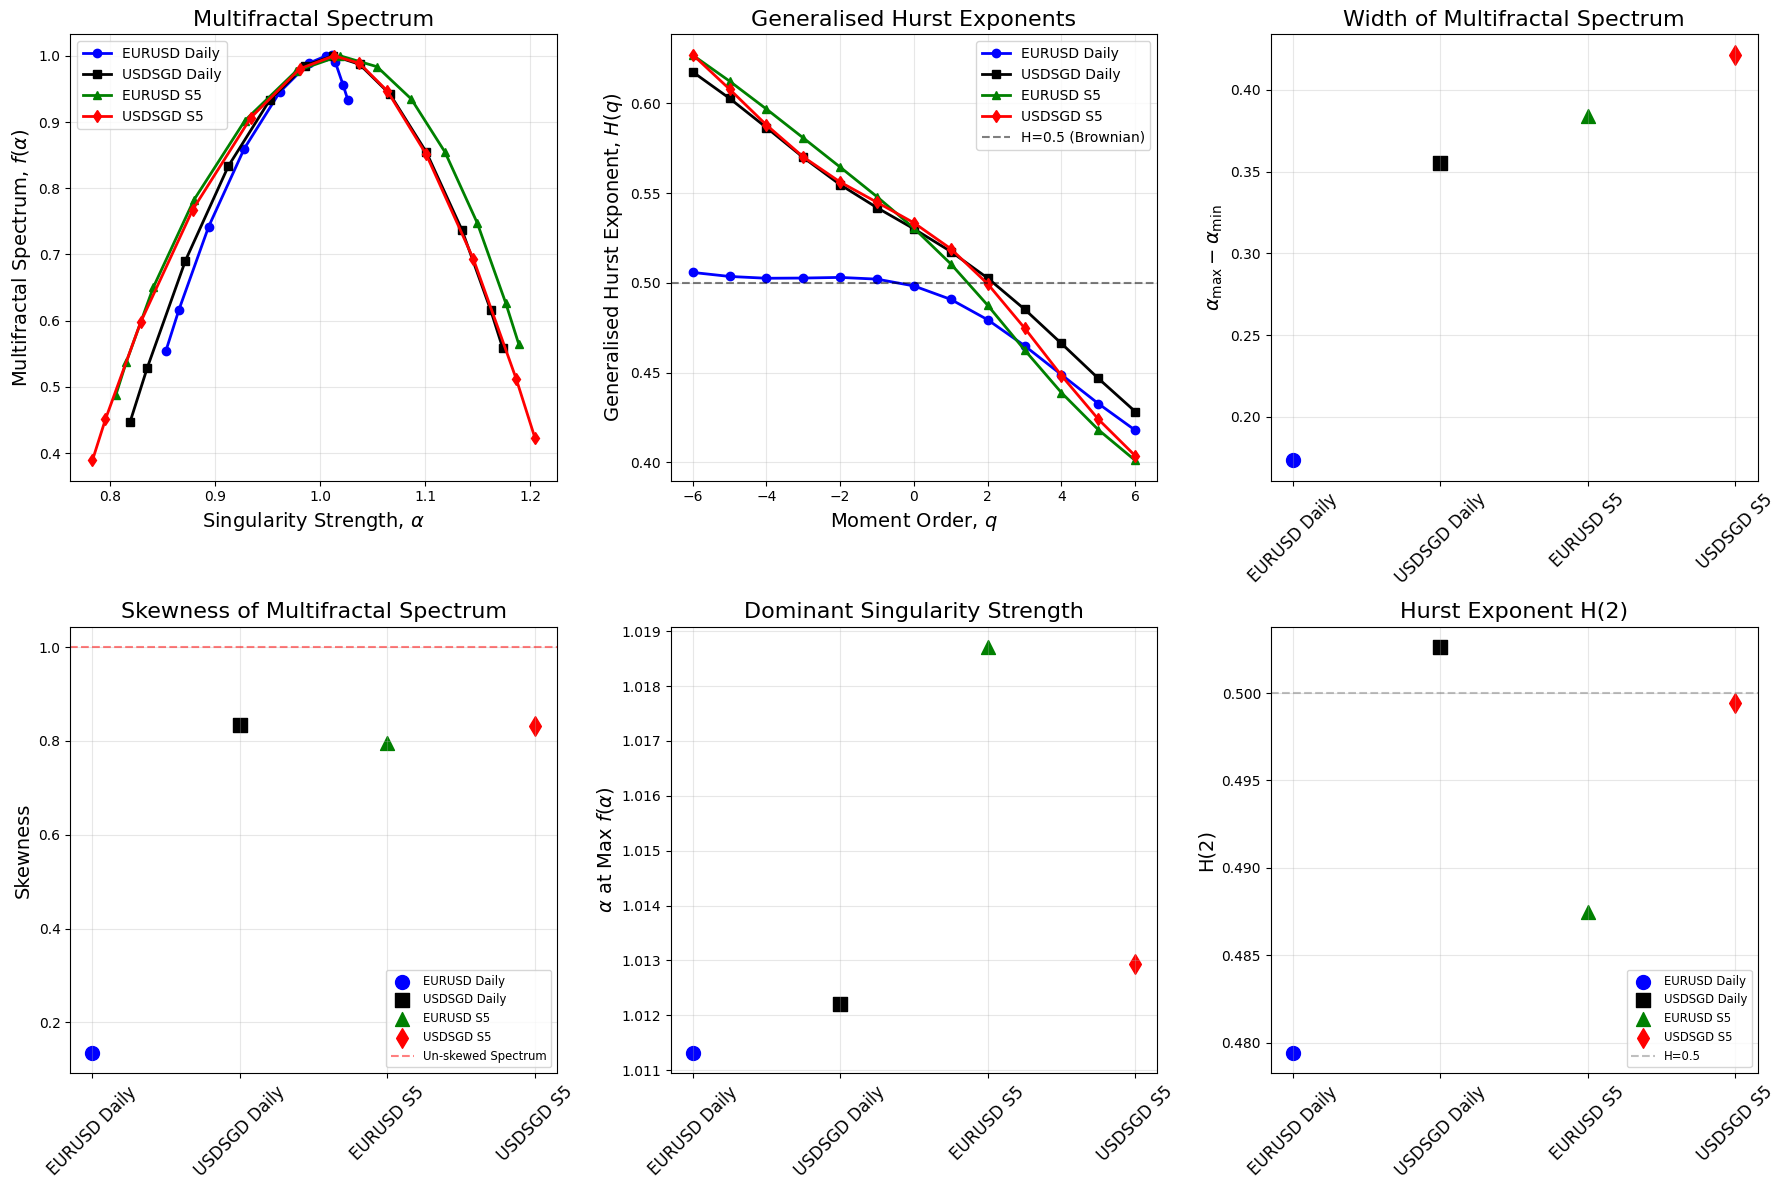

In [50]:
plot_multifractal_analysis(
    alphas_list=alphas_1,
    f_alphas_list=f_alphas_1, 
    hs_list=hs_1,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_raw_r_full_s5_data")

s_min - very arbitray but i found length of series / s_min = around 260 to work well. 

## messy abs r

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_29389/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


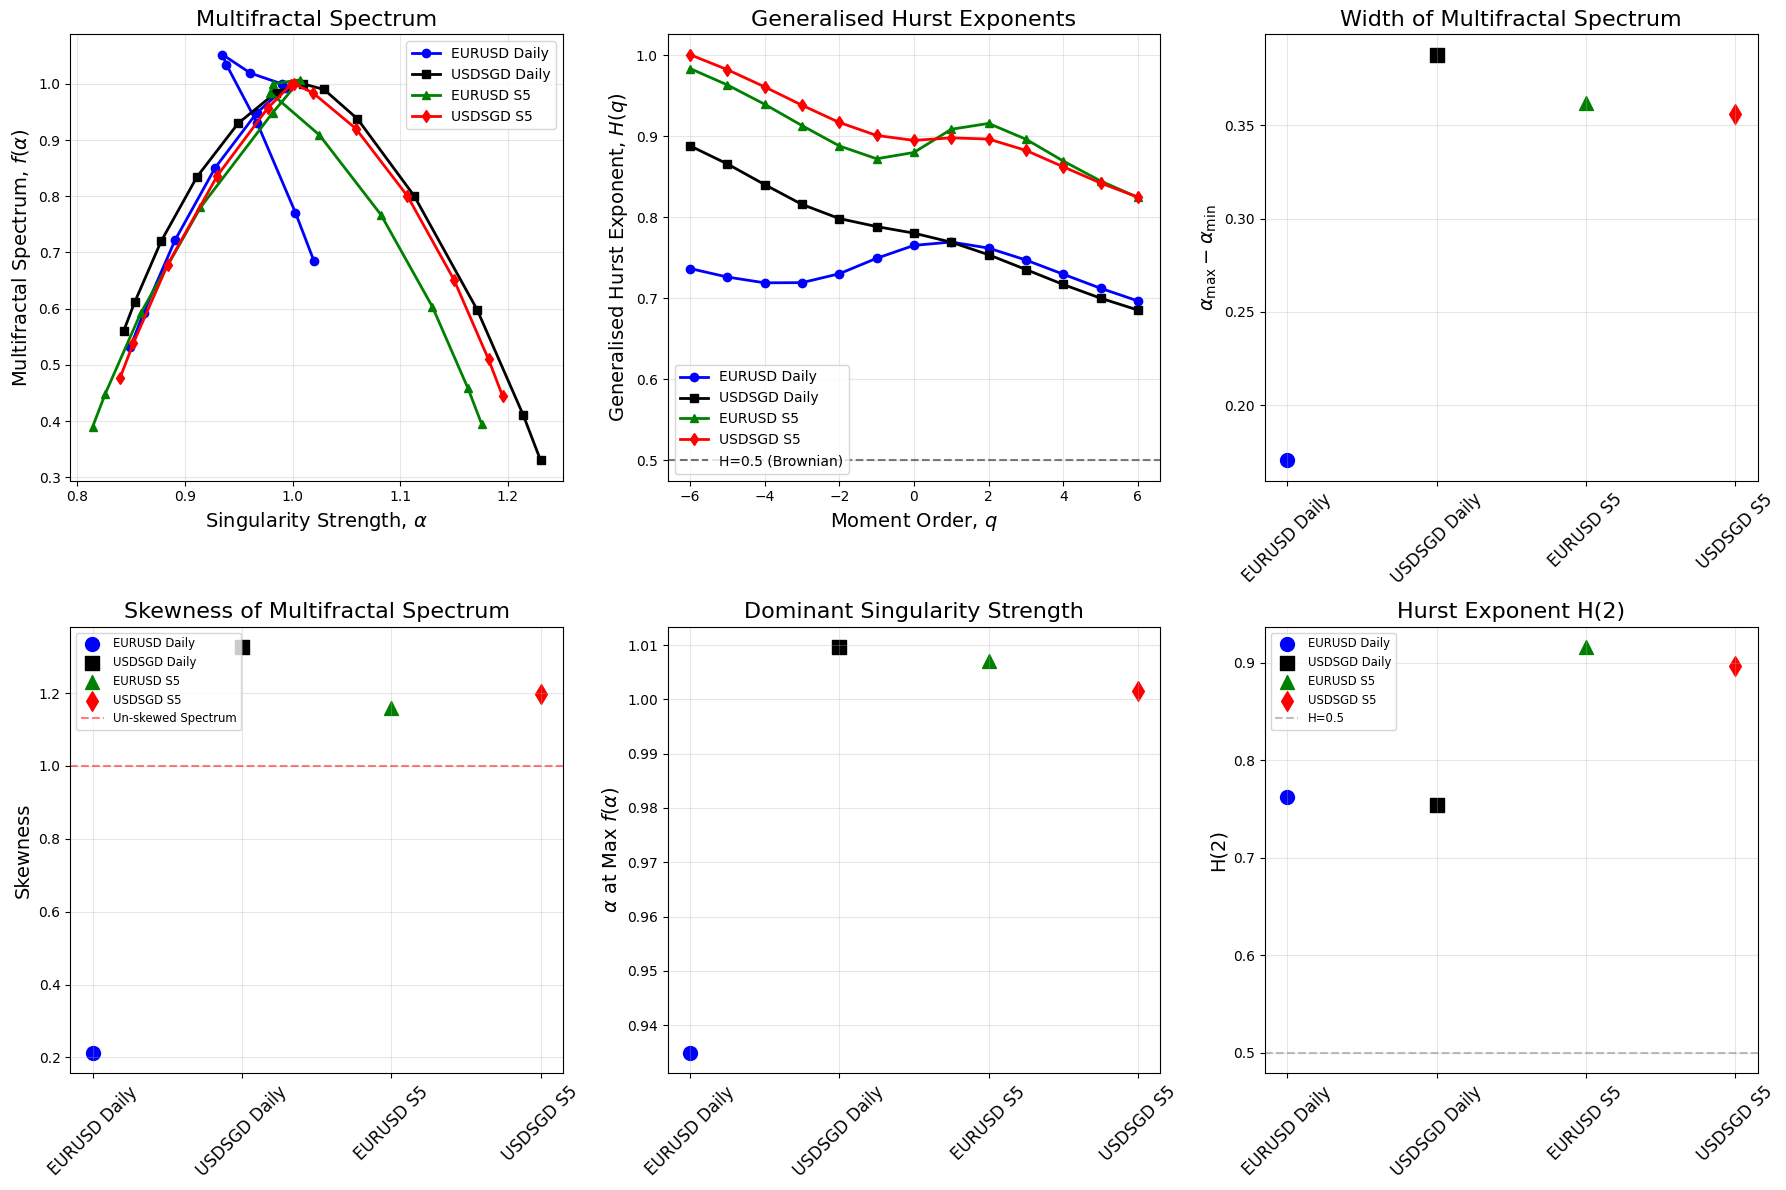

In [63]:
hs_1 = np.zeros((len(types), len(qs)))
alphas_1 = np.zeros((len(types), len(qs)))
f_alphas_1 = np.zeros((len(types), len(qs)))
taos_1 = np.zeros((len(types), len(qs)))
F_qs = []
sss = []
datas = [euro_d, sgd_d, euro_s5, sgd_s5]

for i in range(len(types)):
    if i <2:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], taos_1[i, :], F_qs_i, ss_i  = get_all_spectrum(datas[i], versions[1], qs=qs, s_min = 10, detrend=False)
    else:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], taos_1[i, :], F_qs_i, ss_i  = get_all_spectrum(datas[i], versions[1], qs=qs, s_min = 2000, detrend=False)

    F_qs.append(F_qs_i)
    sss.append(ss_i)

plot_multifractal_analysis(
    alphas_list=alphas_1,
    f_alphas_list=f_alphas_1, 
    hs_list=hs_1,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_abs_r_full_s5_data")

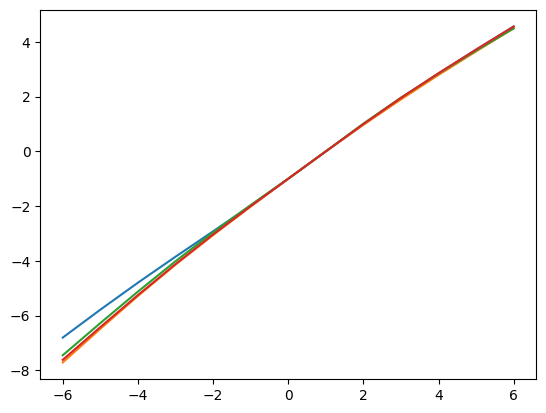

In [64]:
for i in range(len(datas)):
    plt.plot(qs, taos_1[i])

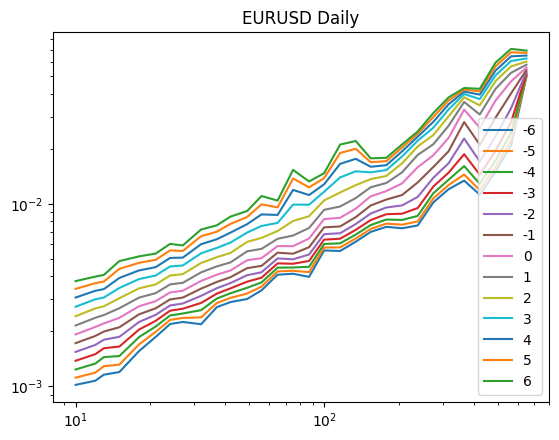

In [65]:
for i in range(len(qs)):
    plt.plot(sss[0], F_qs[0][i], label = qs[i])
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f"{types[0]}")
    plt.legend()

## messy squared r

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_27719/2068664361.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


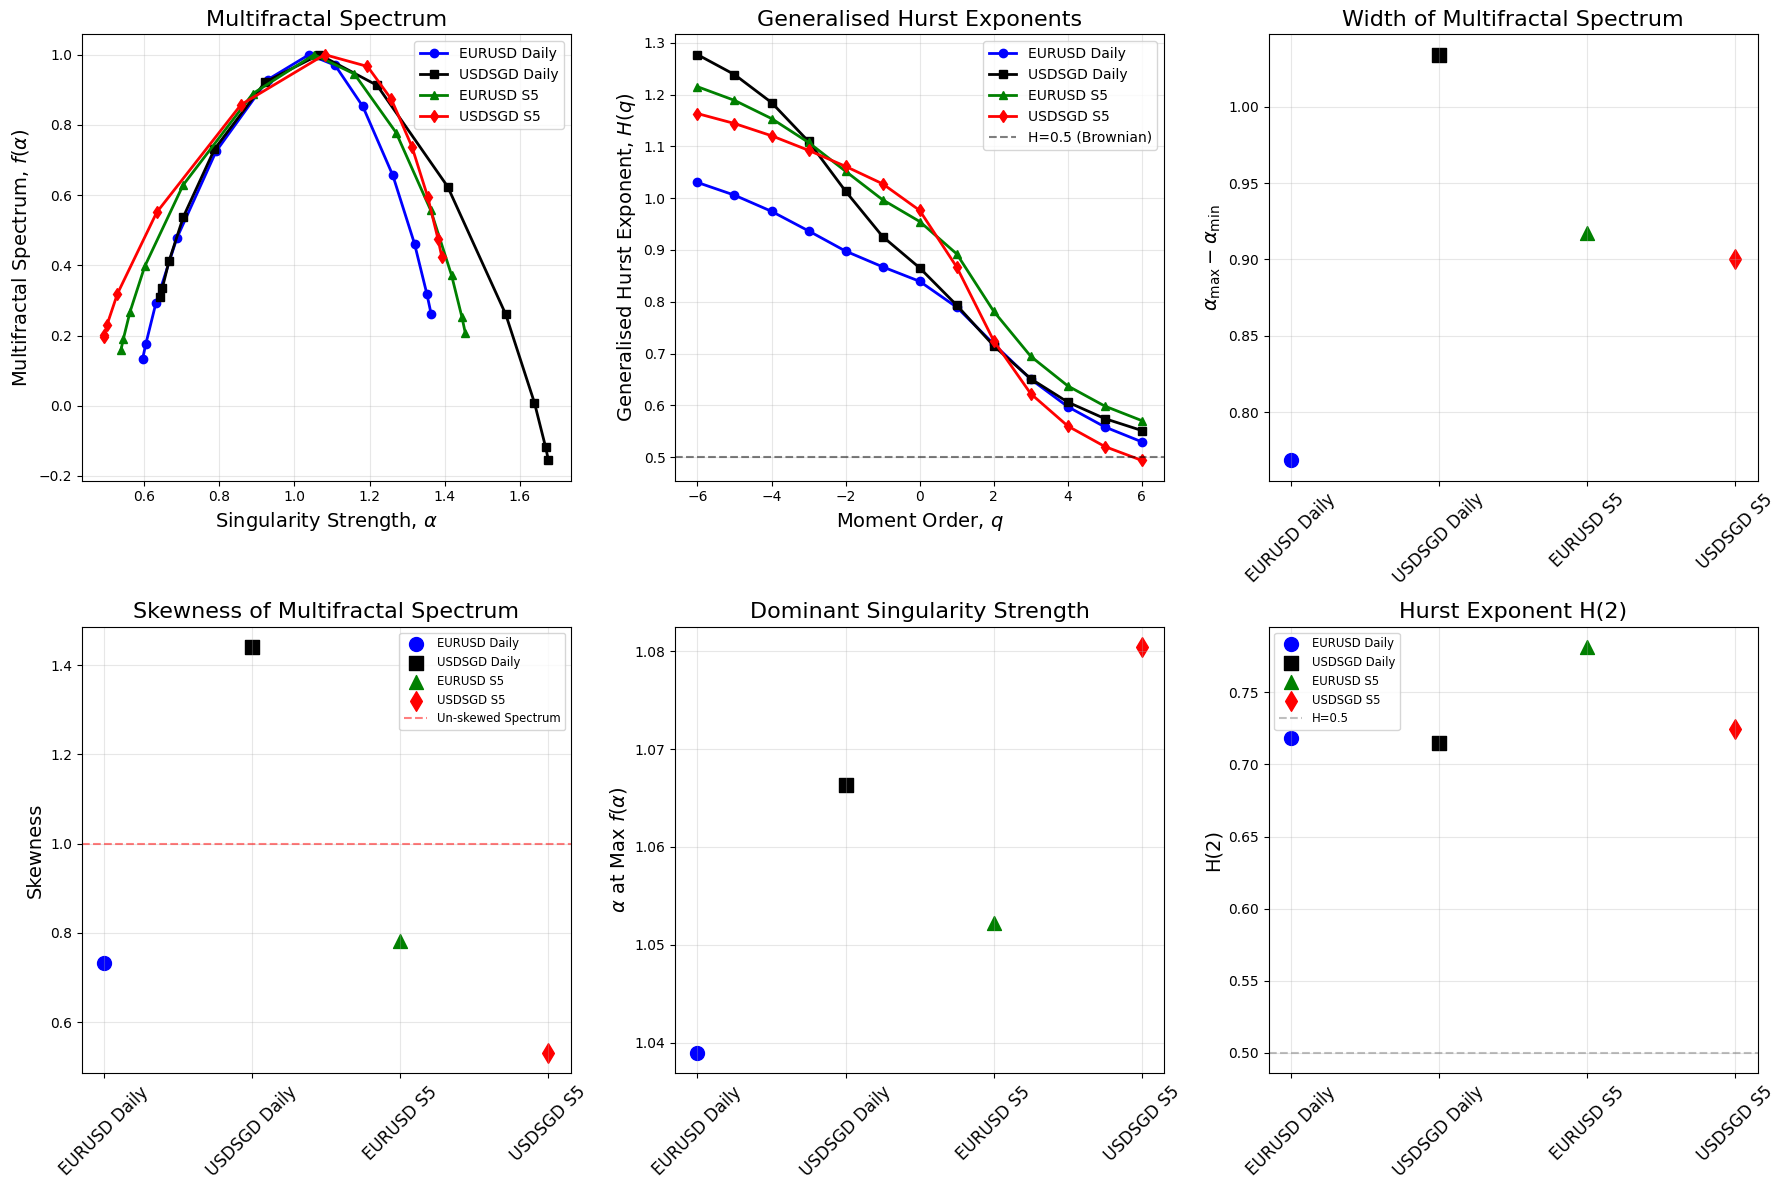

In [17]:
hs_1 = np.zeros((len(types), len(qs)))
alphas_1 = np.zeros((len(types), len(qs)))
f_alphas_1 = np.zeros((len(types), len(qs)))
taos_1 = np.zeros((len(types), len(qs)))
datas = [euro_d, sgd_d, euro_s5, sgd_s5]

for i in range(len(types)):
    if i <2:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], taos_1[i, :], _ = get_all_spectrum(datas[i], versions[2], qs=qs, s_min = 10, detrend=False)
    else:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], taos_1[i, :], _ = get_all_spectrum(datas[i], versions[2], qs=qs, s_min = 2000, detrend=False)
        

plot_multifractal_analysis(
    alphas_list=alphas_1,
    f_alphas_list=f_alphas_1, 
    hs_list=hs_1,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_squared_r_full_s5_data")

## trading hours raw r

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_30113/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


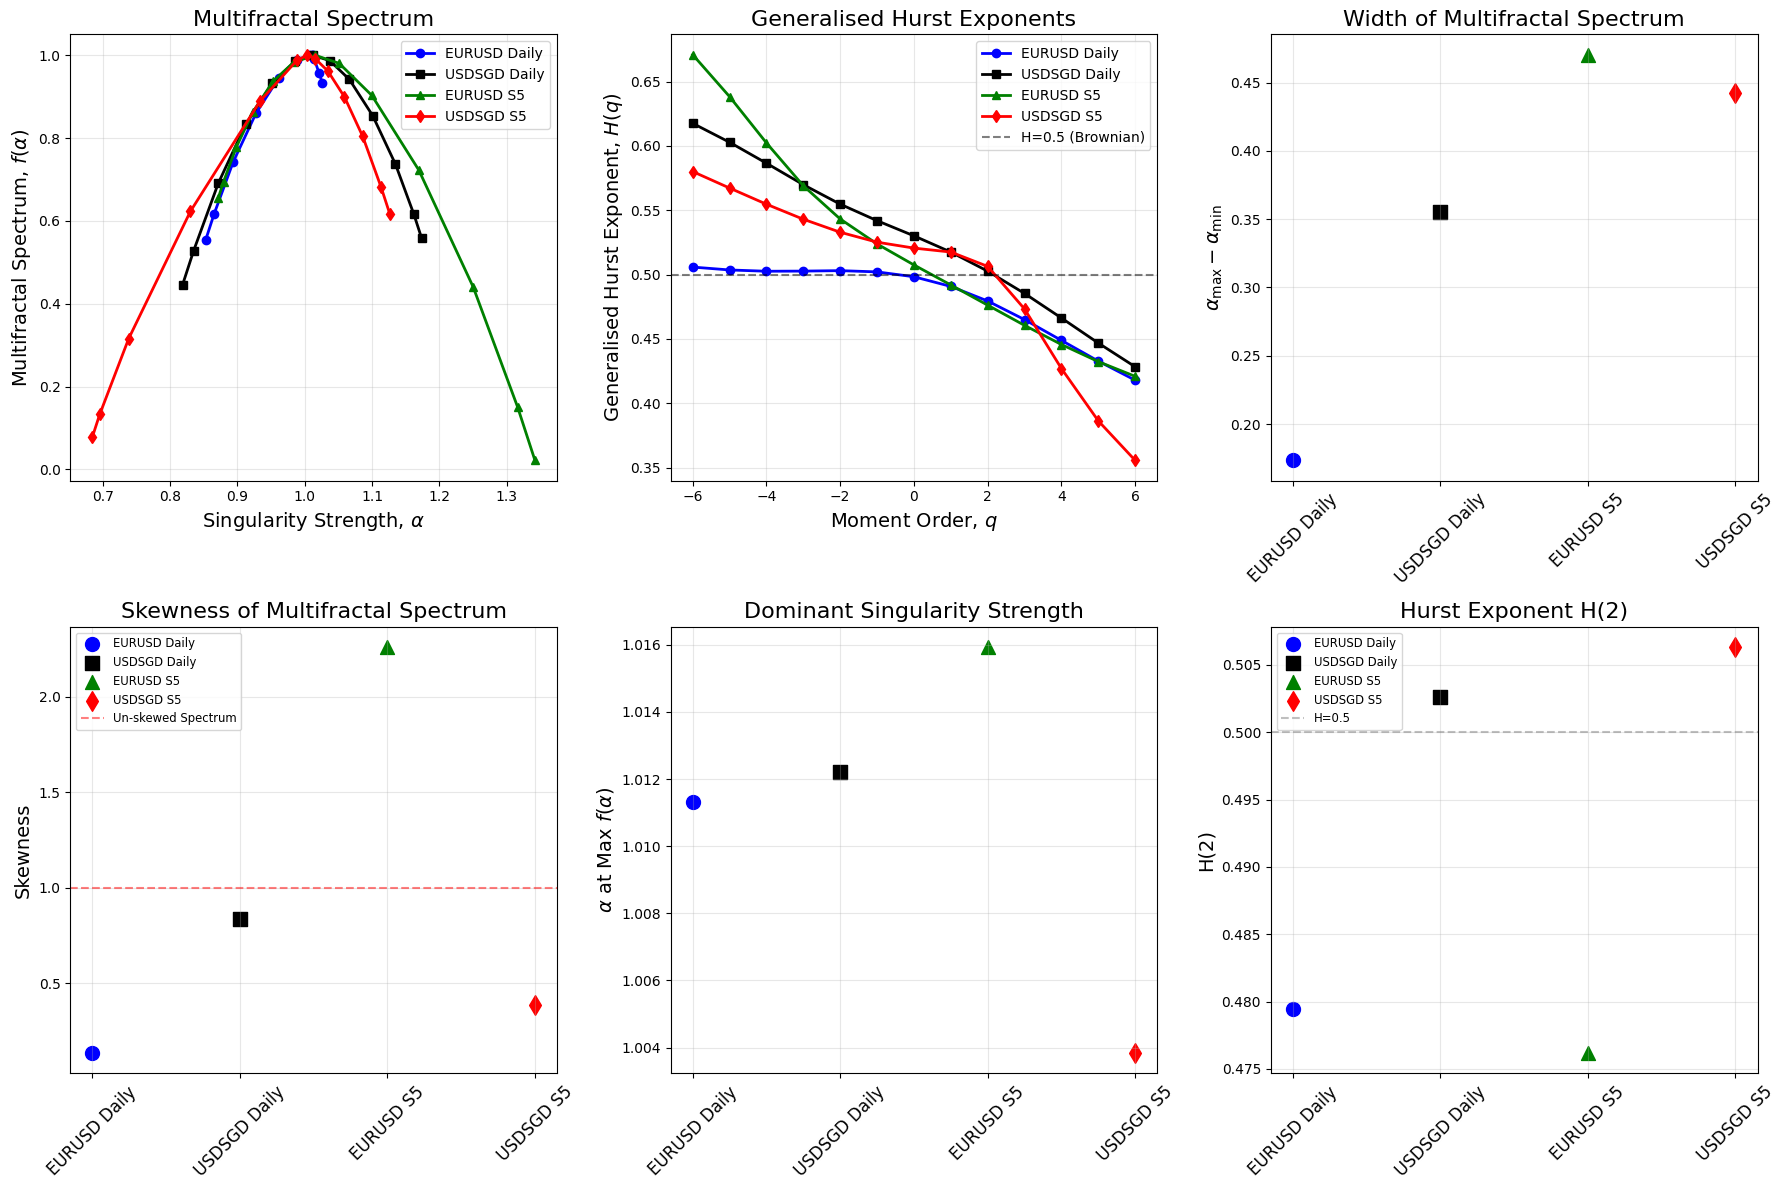

In [10]:
hs_1 = np.zeros((len(types), len(qs)))
alphas_1 = np.zeros((len(types), len(qs)))
f_alphas_1 = np.zeros((len(types), len(qs)))
F_qs = []
sss = []
datas = [euro_d, sgd_d, euro_s5_clean, sgd_s5_clean]

for i in range(len(types)):
    if i <2:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _ , F_qs_i, ss_i = get_all_spectrum(datas[i], versions[0], qs=qs, s_min = 10, detrend=False)
    else:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _, F_qs_i, ss_i = get_all_spectrum(datas[i], versions[0], qs=qs, s_min = 1000, m=1, detrend=False)

    F_qs.append(F_qs_i)
    sss.append(ss_i)

plot_multifractal_analysis(
    alphas_list=alphas_1,
    f_alphas_list=f_alphas_1, 
    hs_list=hs_1,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_raw_r_trading_hours_s5_data"
    )

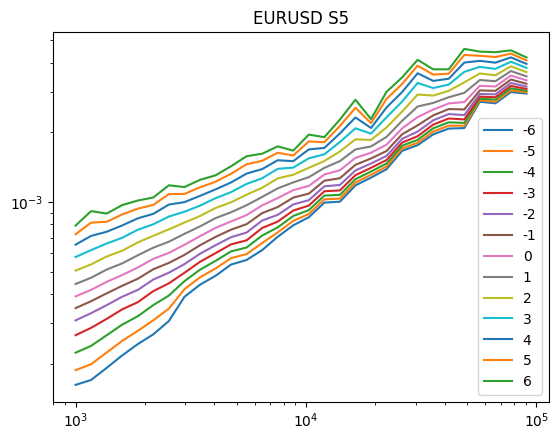

In [6]:
for i in range(len(qs)):
    plt.plot(sss[2], F_qs[2][i], label = qs[i])
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f"{types[2]}")
    plt.legend()

## trading hours abs r

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_30113/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


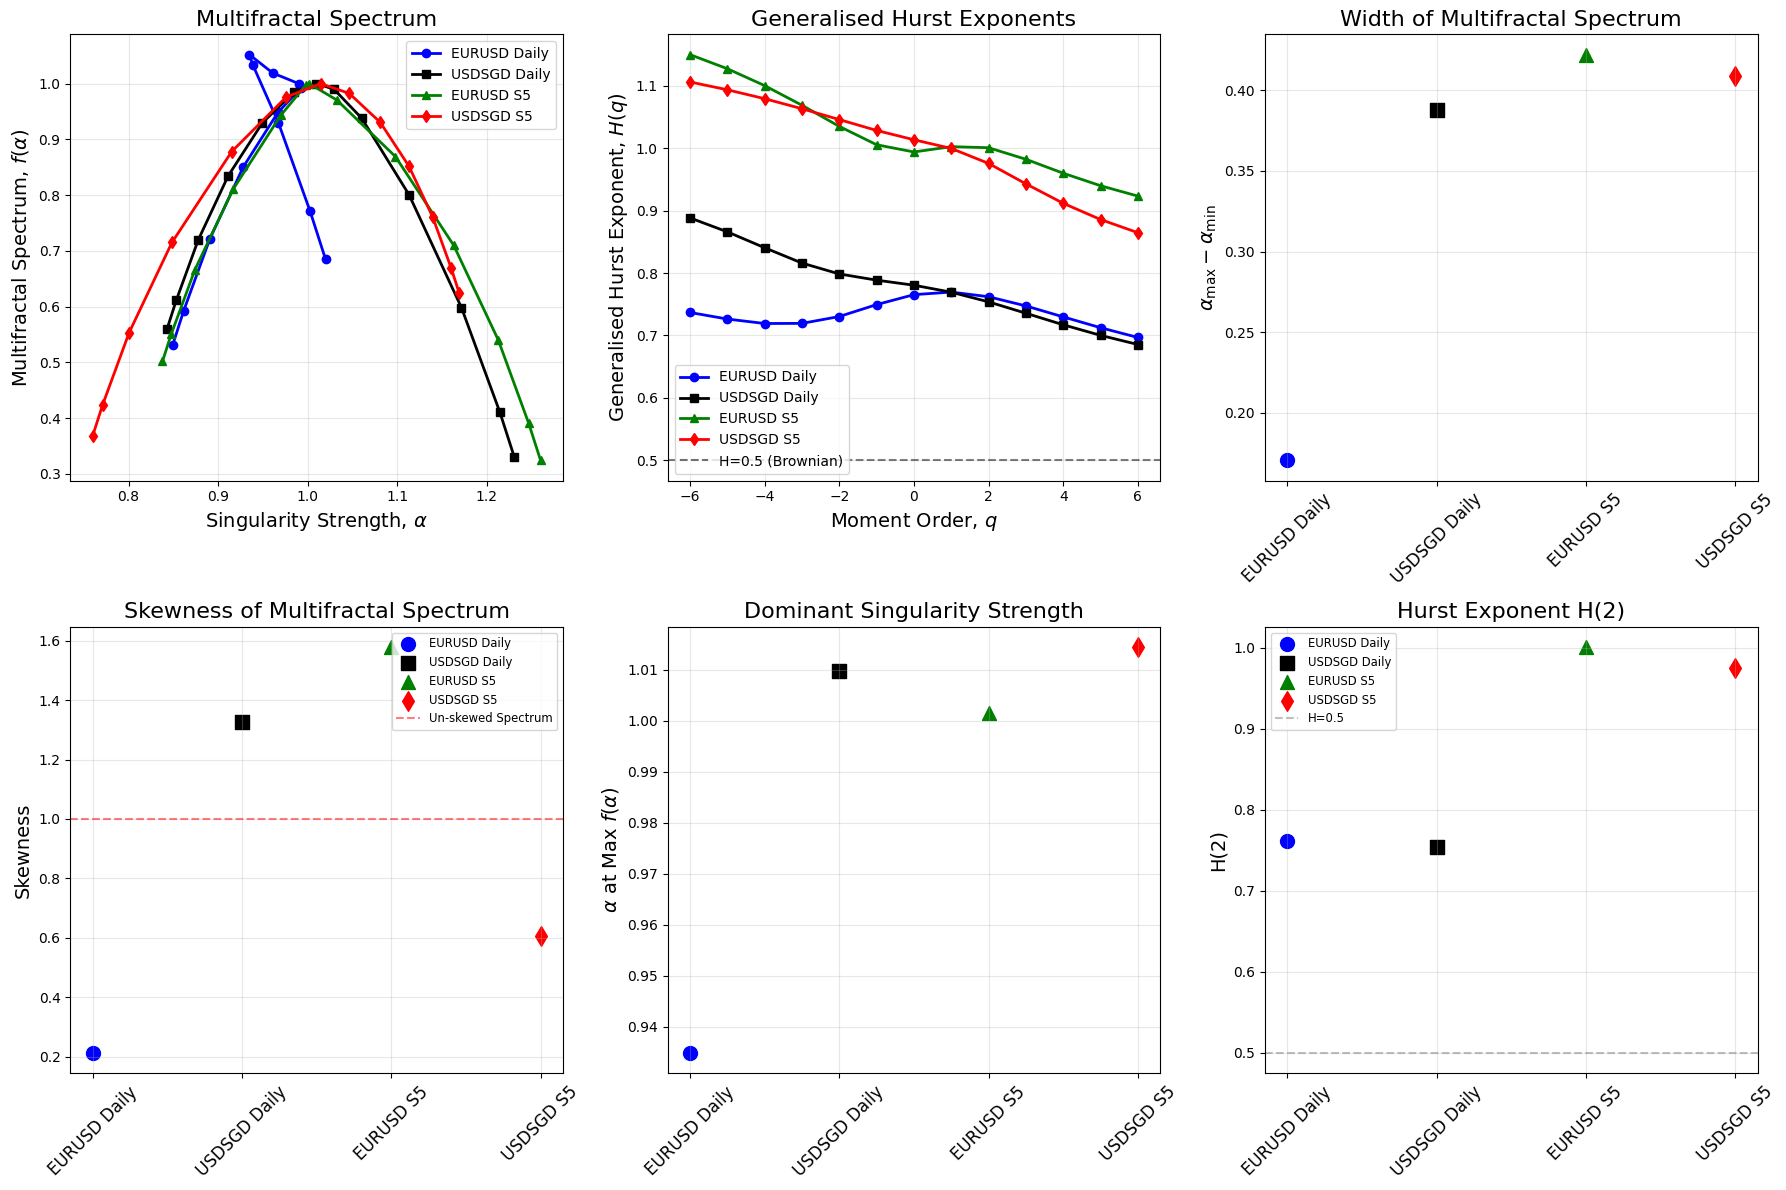

In [11]:
hs_1 = np.zeros((len(types), len(qs)))
alphas_1 = np.zeros((len(types), len(qs)))
f_alphas_1 = np.zeros((len(types), len(qs)))
F_qs = []
sss = []
datas = [euro_d, sgd_d, euro_s5_clean, sgd_s5_clean]

for i in range(len(types)):
    if i <2:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _ , F_qs_i, ss_i = get_all_spectrum(datas[i], versions[1], qs=qs, s_min = 10, detrend=False)
    else:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _, F_qs_i, ss_i = get_all_spectrum(datas[i], versions[1], qs=qs, s_min = 1000, m=1, detrend=False)

    F_qs.append(F_qs_i)
    sss.append(ss_i)

plot_multifractal_analysis(
    alphas_list=alphas_1,
    f_alphas_list=f_alphas_1, 
    hs_list=hs_1,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_abs_r_trading_hours_s5_data"
    )

## trading hours squared r

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_30113/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


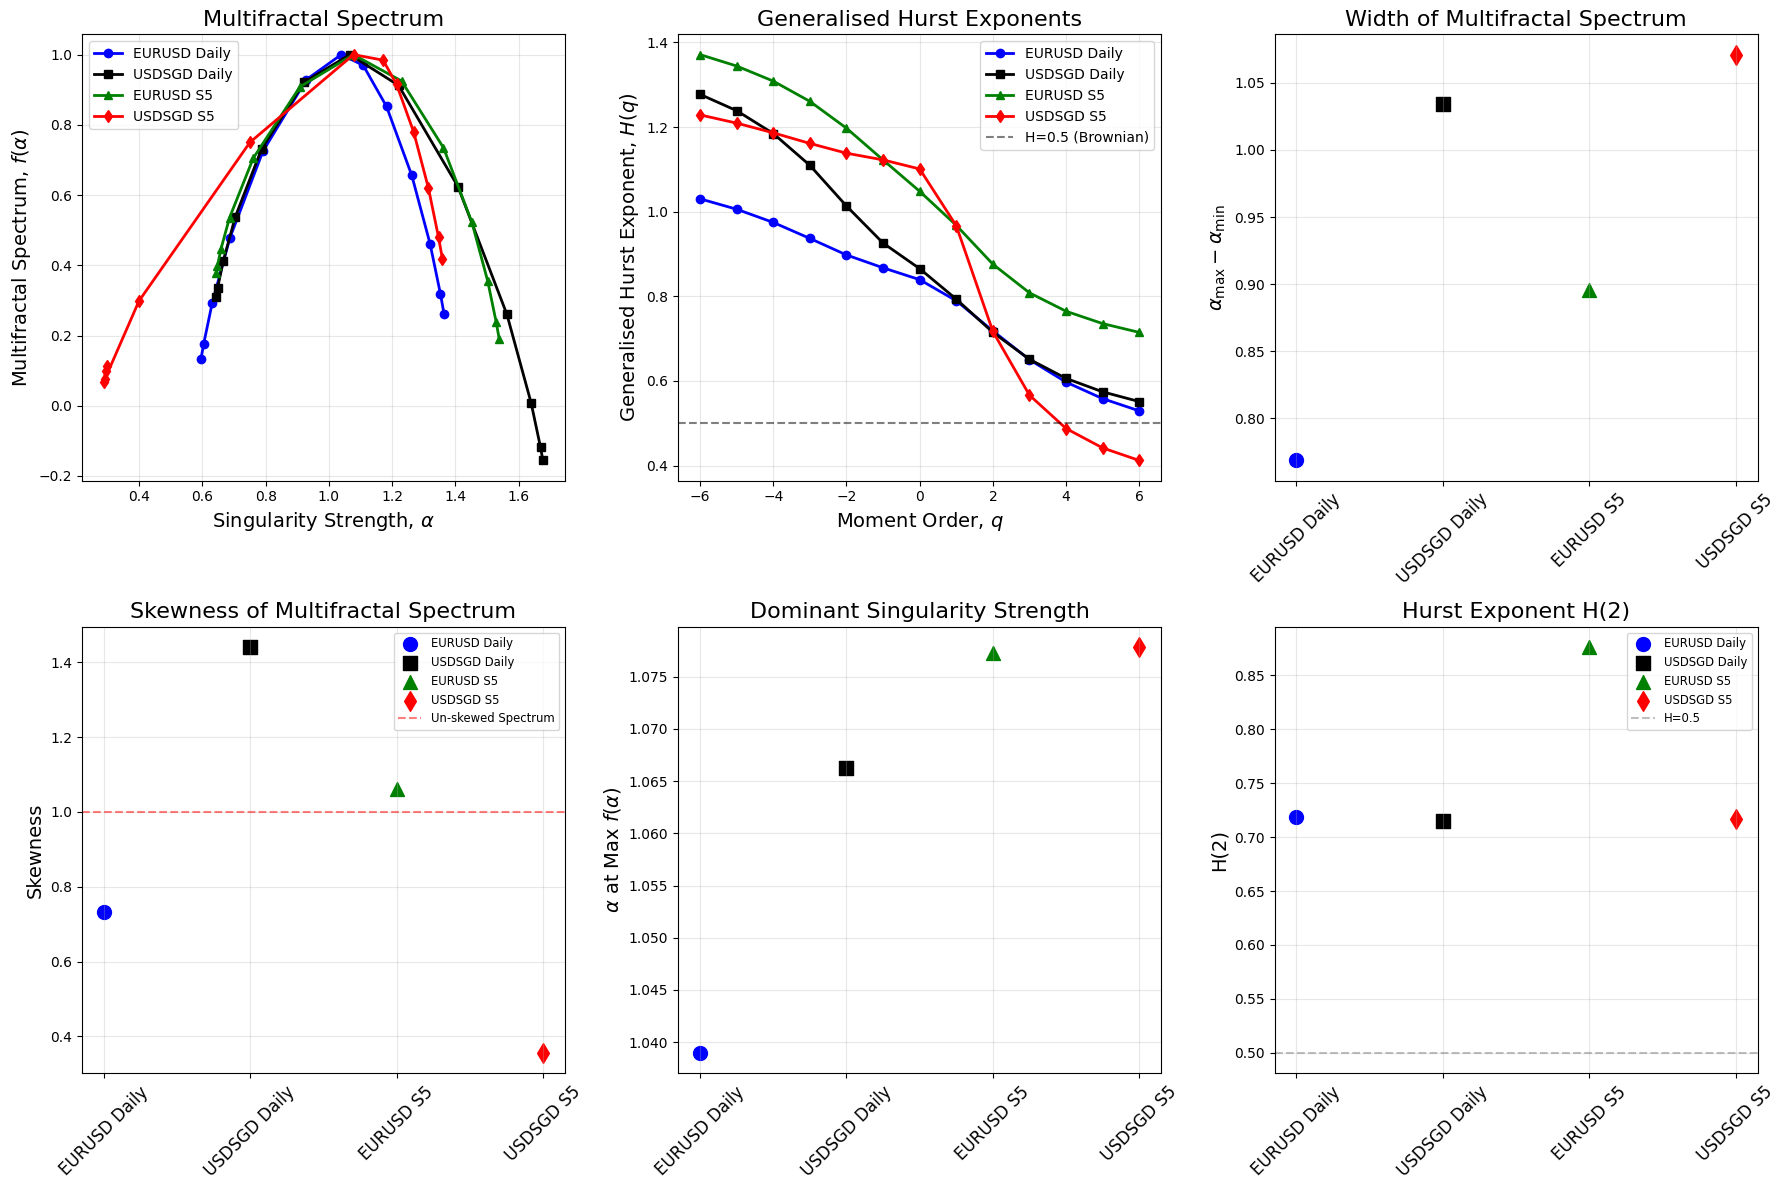

In [12]:
hs_1 = np.zeros((len(types), len(qs)))
alphas_1 = np.zeros((len(types), len(qs)))
f_alphas_1 = np.zeros((len(types), len(qs)))
F_qs = []
sss = []
datas = [euro_d, sgd_d, euro_s5_clean, sgd_s5_clean]

for i in range(len(types)):
    if i <2:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _ , F_qs_i, ss_i = get_all_spectrum(datas[i], versions[2], qs=qs, s_min = 10, detrend=False)
    else:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _, F_qs_i, ss_i = get_all_spectrum(datas[i], versions[2], qs=qs, s_min = 1000, m=1, detrend=False)

    F_qs.append(F_qs_i)
    sss.append(ss_i)

plot_multifractal_analysis(
    alphas_list=alphas_1,
    f_alphas_list=f_alphas_1, 
    hs_list=hs_1,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_squared_r_trading_hours_s5_data"
    )

## trading hours detrend raw r

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_30113/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


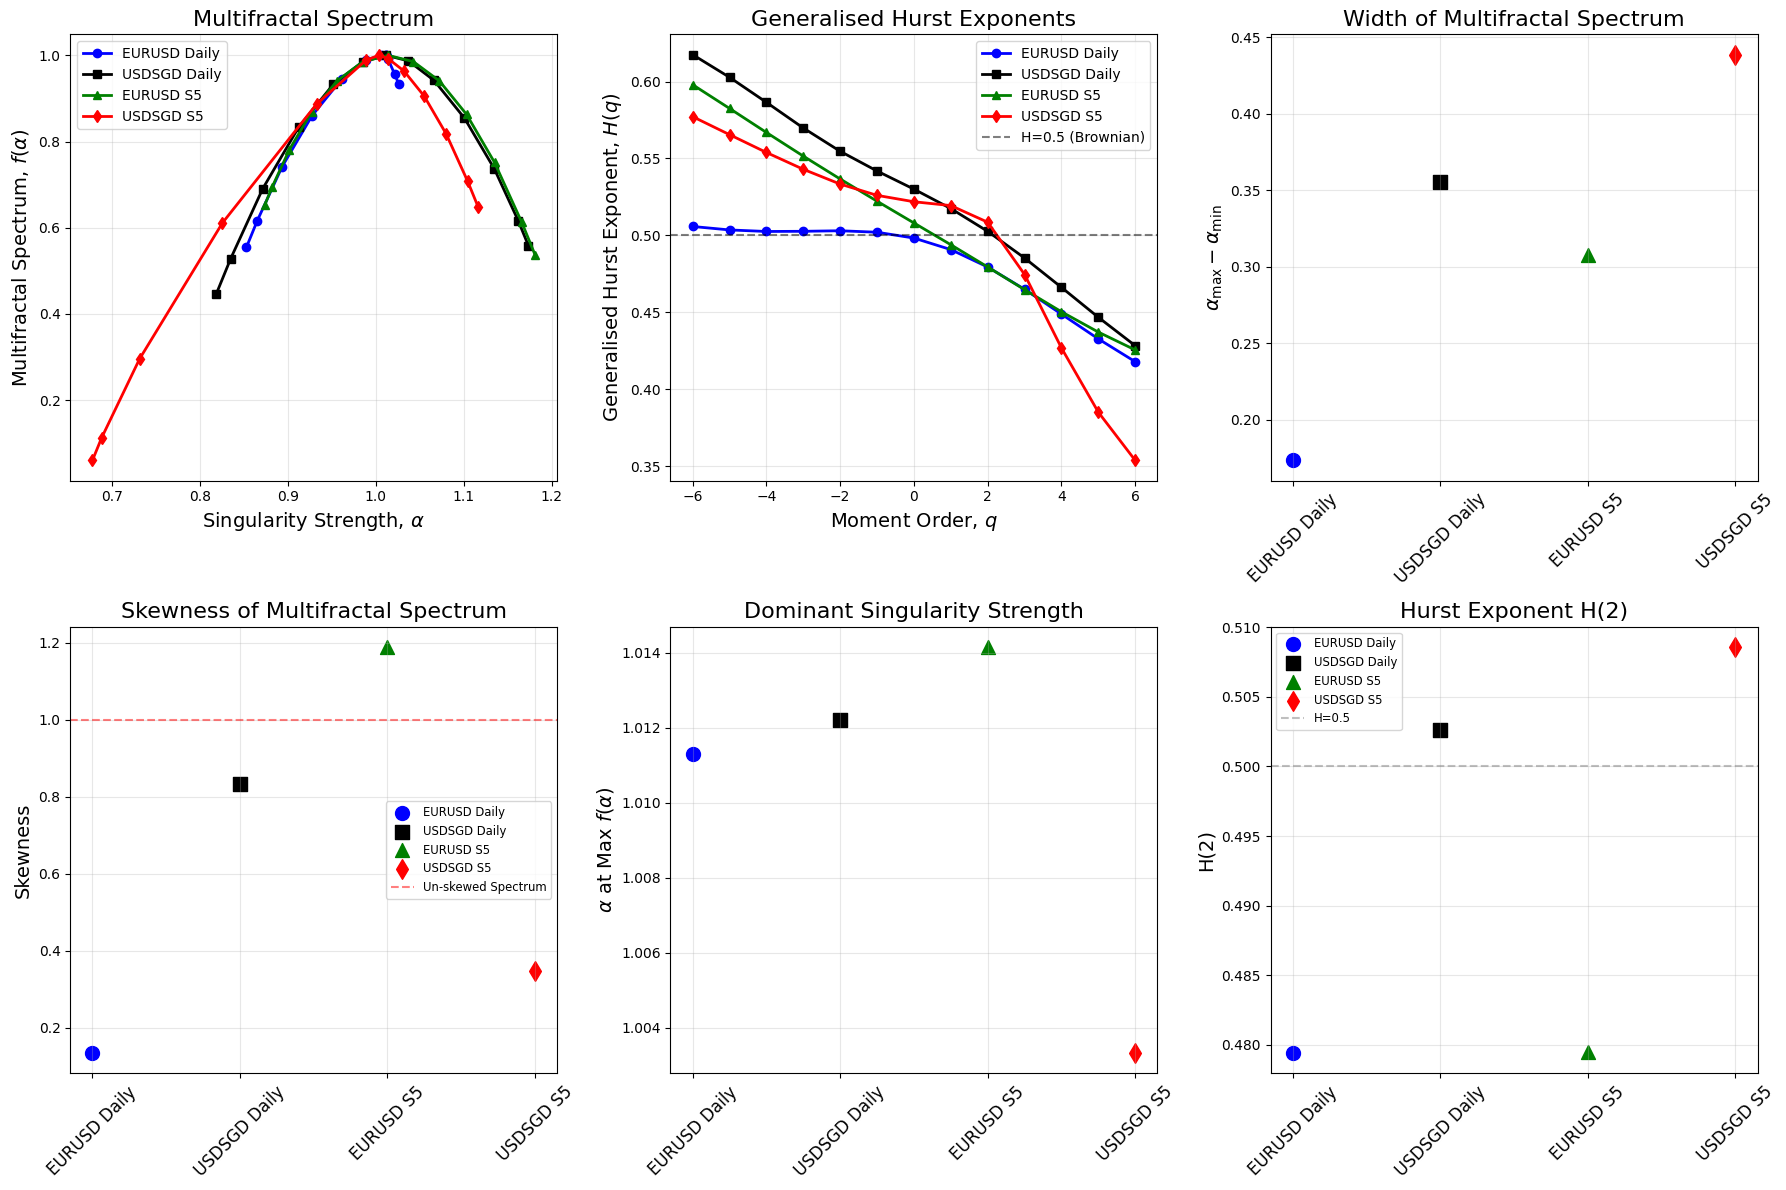

In [13]:
hs_1 = np.zeros((len(types), len(qs)))
alphas_1 = np.zeros((len(types), len(qs)))
f_alphas_1 = np.zeros((len(types), len(qs)))
F_qs = []
sss = []
datas = [euro_d, sgd_d, euro_s5_clean, sgd_s5_clean]

for i in range(len(types)):
    if i <2:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _ , F_qs_i, ss_i = get_all_spectrum(datas[i], versions[0], qs=qs, s_min = 10, detrend=False)
    else:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _, F_qs_i, ss_i = get_all_spectrum(datas[i], versions[0], qs=qs, s_min = 1000, m=1, detrend=True)

    F_qs.append(F_qs_i)
    sss.append(ss_i)

plot_multifractal_analysis(
    alphas_list=alphas_1,
    f_alphas_list=f_alphas_1, 
    hs_list=hs_1,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_raw_r_trading_hours_DETREND__s5_data"
    )

## trading hours detrend abs r

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_30113/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


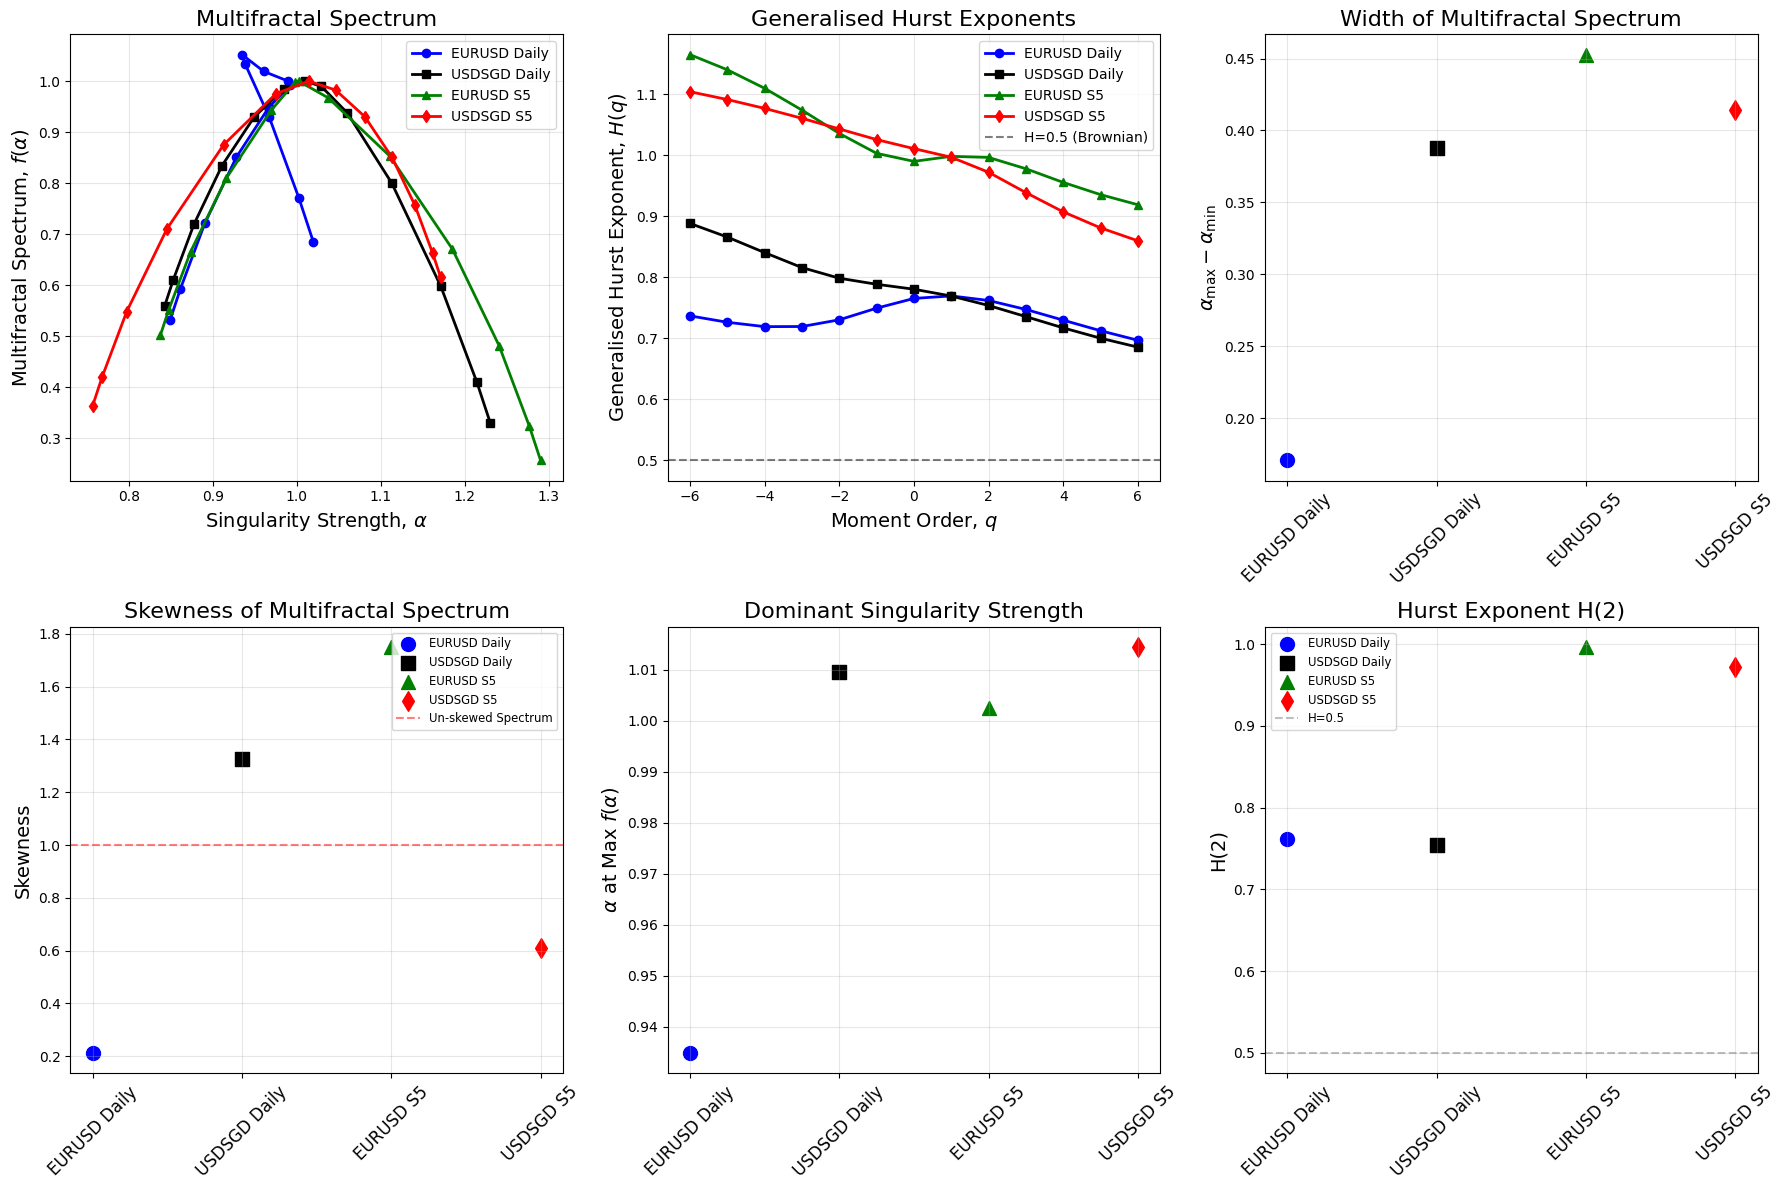

In [14]:
hs_1 = np.zeros((len(types), len(qs)))
alphas_1 = np.zeros((len(types), len(qs)))
f_alphas_1 = np.zeros((len(types), len(qs)))
F_qs = []
sss = []
datas = [euro_d, sgd_d, euro_s5_clean, sgd_s5_clean]

for i in range(len(types)):
    if i <2:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _ , F_qs_i, ss_i = get_all_spectrum(datas[i], versions[1], qs=qs, s_min = 10, detrend=False)
    else:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _, F_qs_i, ss_i = get_all_spectrum(datas[i], versions[1], qs=qs, s_min = 1000, m=1, detrend=True)

    F_qs.append(F_qs_i)
    sss.append(ss_i)

plot_multifractal_analysis(
    alphas_list=alphas_1,
    f_alphas_list=f_alphas_1, 
    hs_list=hs_1,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_abs_r_trading_hours_DETREND__s5_data"
    )

## tradin hours detrend squared r

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_30113/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


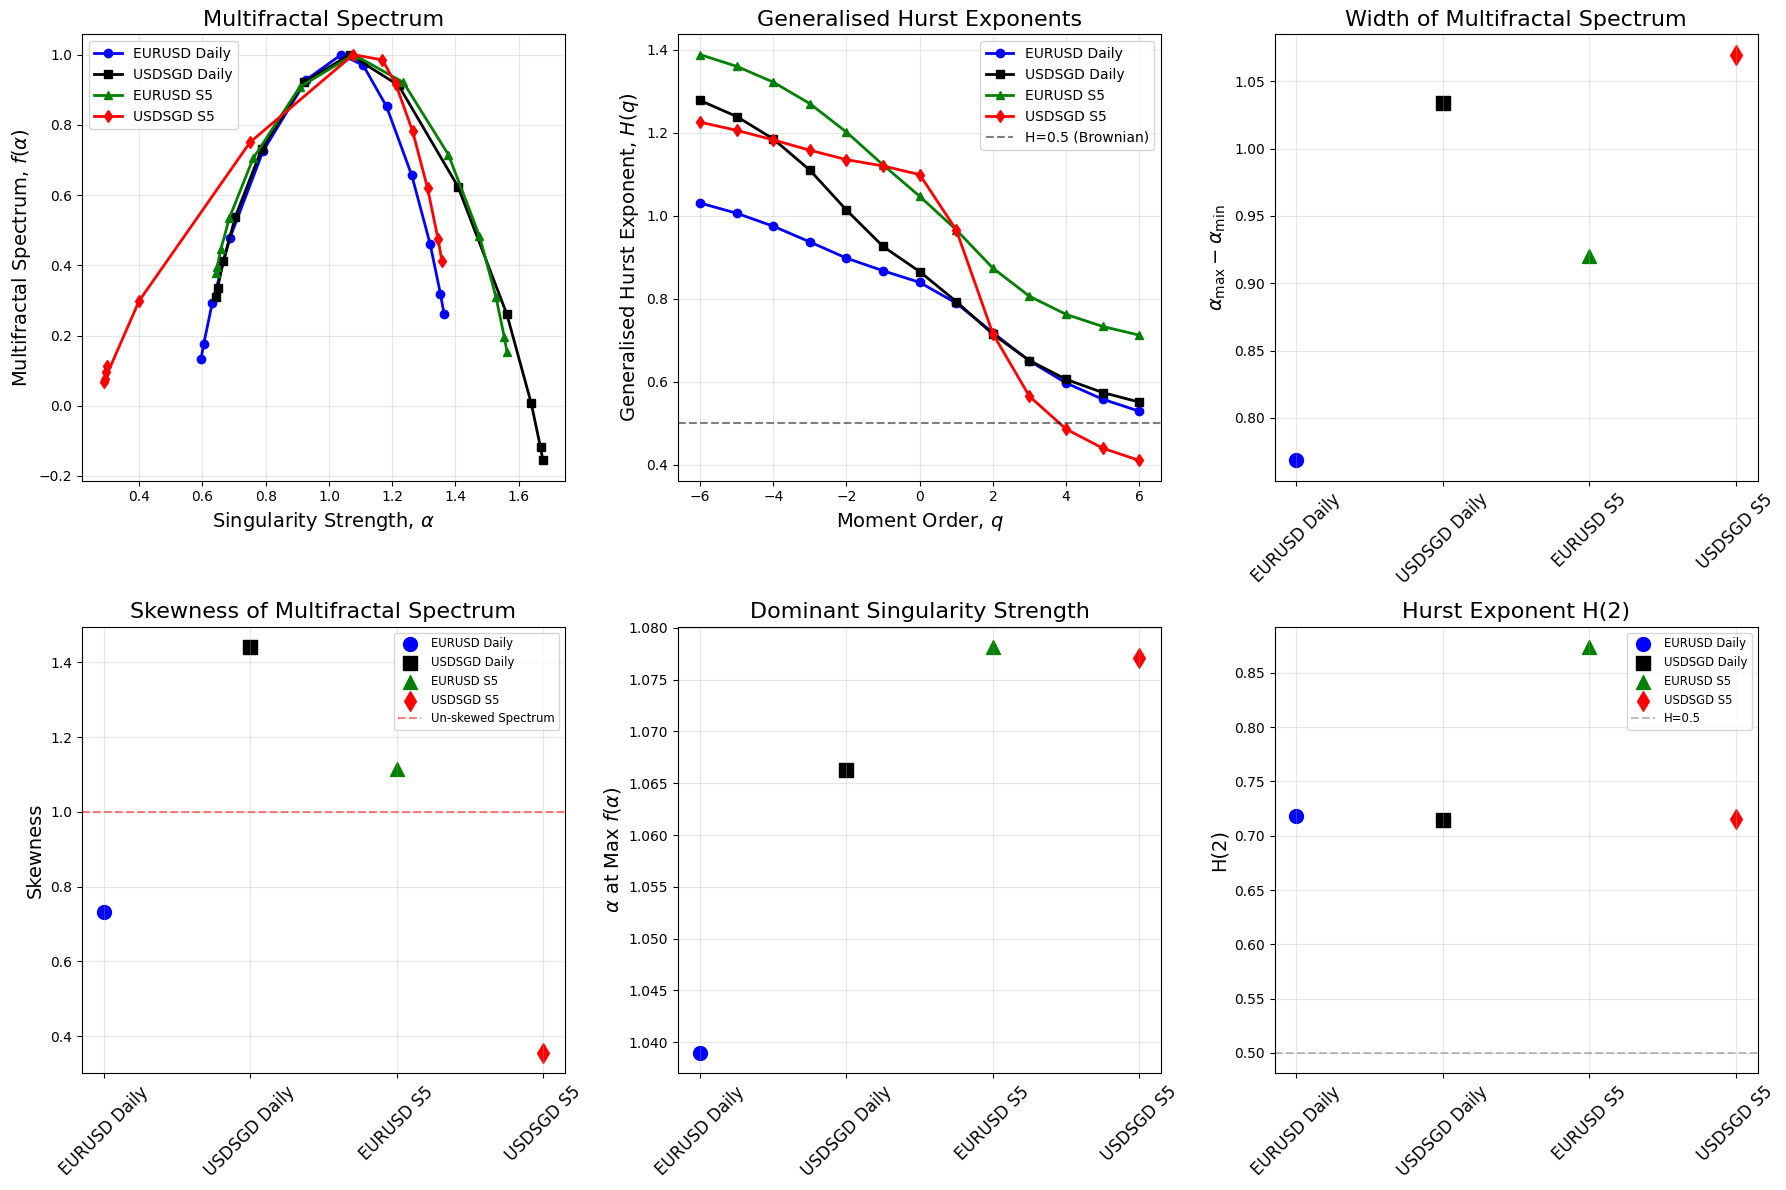

In [15]:
hs_1 = np.zeros((len(types), len(qs)))
alphas_1 = np.zeros((len(types), len(qs)))
f_alphas_1 = np.zeros((len(types), len(qs)))
F_qs = []
sss = []
datas = [euro_d, sgd_d, euro_s5_clean, sgd_s5_clean]

for i in range(len(types)):
    if i <2:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _ , F_qs_i, ss_i = get_all_spectrum(datas[i], versions[2], qs=qs, s_min = 10, detrend=False)
    else:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _, F_qs_i, ss_i = get_all_spectrum(datas[i], versions[2], qs=qs, s_min = 1000, m=1, detrend=True)

    F_qs.append(F_qs_i)
    sss.append(ss_i)

plot_multifractal_analysis(
    alphas_list=alphas_1,
    f_alphas_list=f_alphas_1, 
    hs_list=hs_1,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_squared_r_trading_hours_DETREND__s5_data"
    )

Detrending doesnt really have affect on volatility spectrum. 

# Detrend full series and try that to compare

In [10]:
#precleaning in one
from MFDFA_functions import get_moment_fluctuations_q, get_generalised_hurst, get_mf_spectrum
import numpy as np
from scipy.stats import norm, kurtosis, combine_pvalues
from scipy.stats import t as studt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from MFDFA_new import MFDFA
import pandas as pd
import seaborn as sns
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/S5_EURUSD_mid.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/S5_USDSGD_mid.parquet")
euro_d = pd.read_excel("/Users/alexvillamartin/Documents/MSc Diss/Code/Daily EURUSD spot.xlsx")
sgd_d = pd.read_excel("/Users/alexvillamartin/Documents/MSc Diss/Code/Daily USDSGD spot.xlsx")
euro_d.set_index("Date", inplace=True)
sgd_d.set_index("Date", inplace=True)

euro_d.rename(columns = {
    "Spot": "Mid"
}, inplace = True)
sgd_d.rename(columns = {
    "Spot": "Mid"
}, inplace = True)
length_s5 = len(euro_s5)
euro_s5 = euro_s5.iloc[int(length_s5/2):]
sgd_s5 = sgd_s5.iloc[int(length_s5/2):]
def get_log_returns(df):

    df['Log_r'] = np.log(pd.to_numeric(df['Mid'])).diff()
    df = df.dropna()
    return df
euro_s5 = get_log_returns(euro_s5)
sgd_s5 = get_log_returns(sgd_s5)
euro_d = get_log_returns(euro_d)
sgd_d = get_log_returns(sgd_d)

def remove_first_day_and_last(df):
    df_copy = df.copy()

    first_date = df_copy.index.date[0] 
    last_date = df_copy.index.date[-1]

    mask = (df_copy.index.date != first_date) & (df_copy.index.date != last_date)

    return df_copy[mask]

euro_s5_clean = remove_first_day_and_last(euro_s5)
sgd_s5_clean = remove_first_day_and_last(sgd_s5)

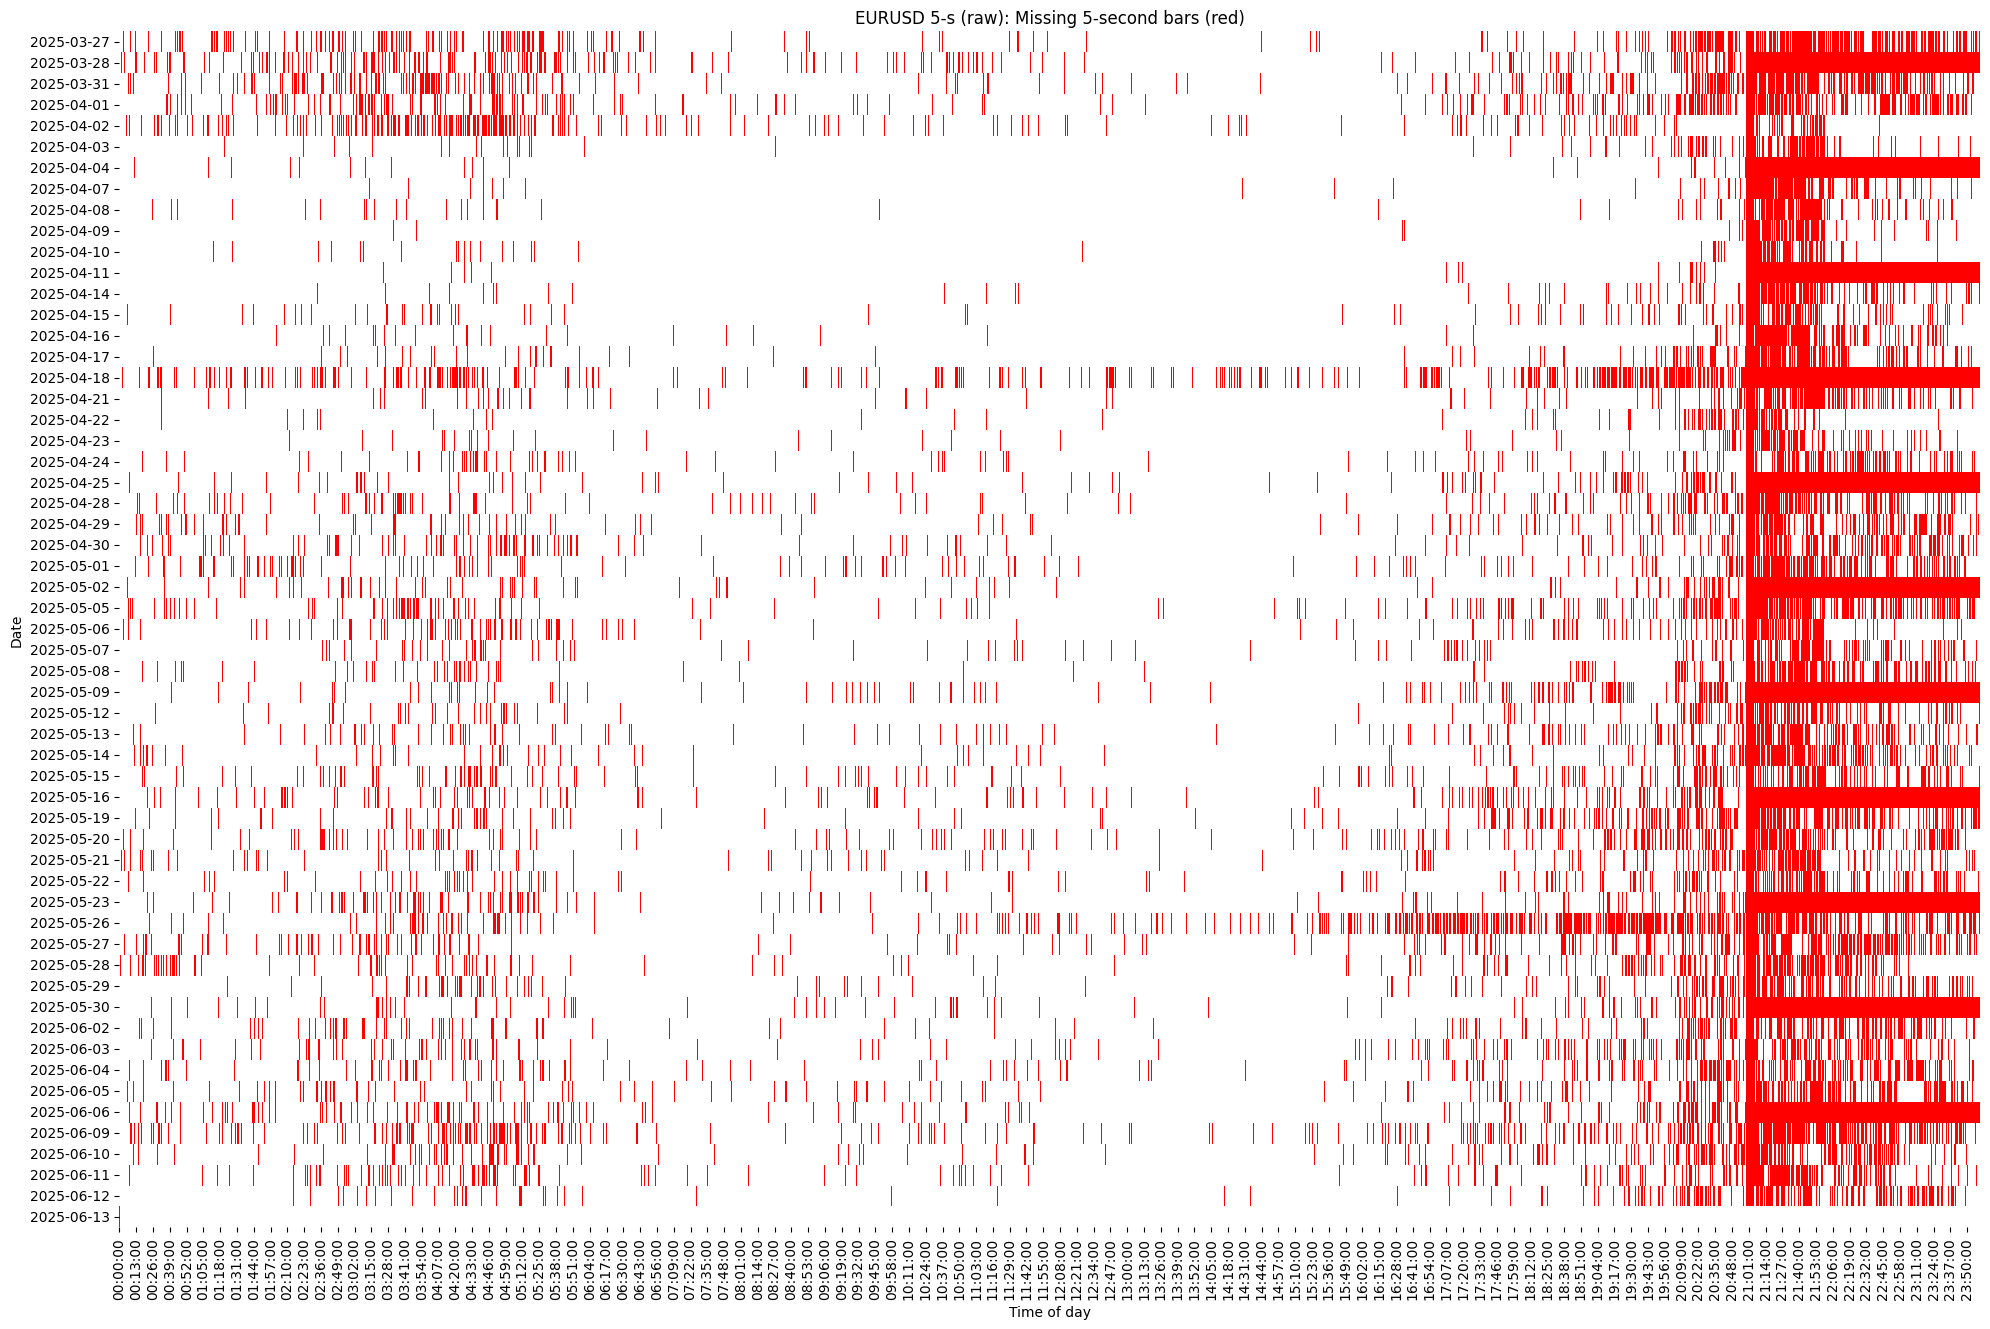

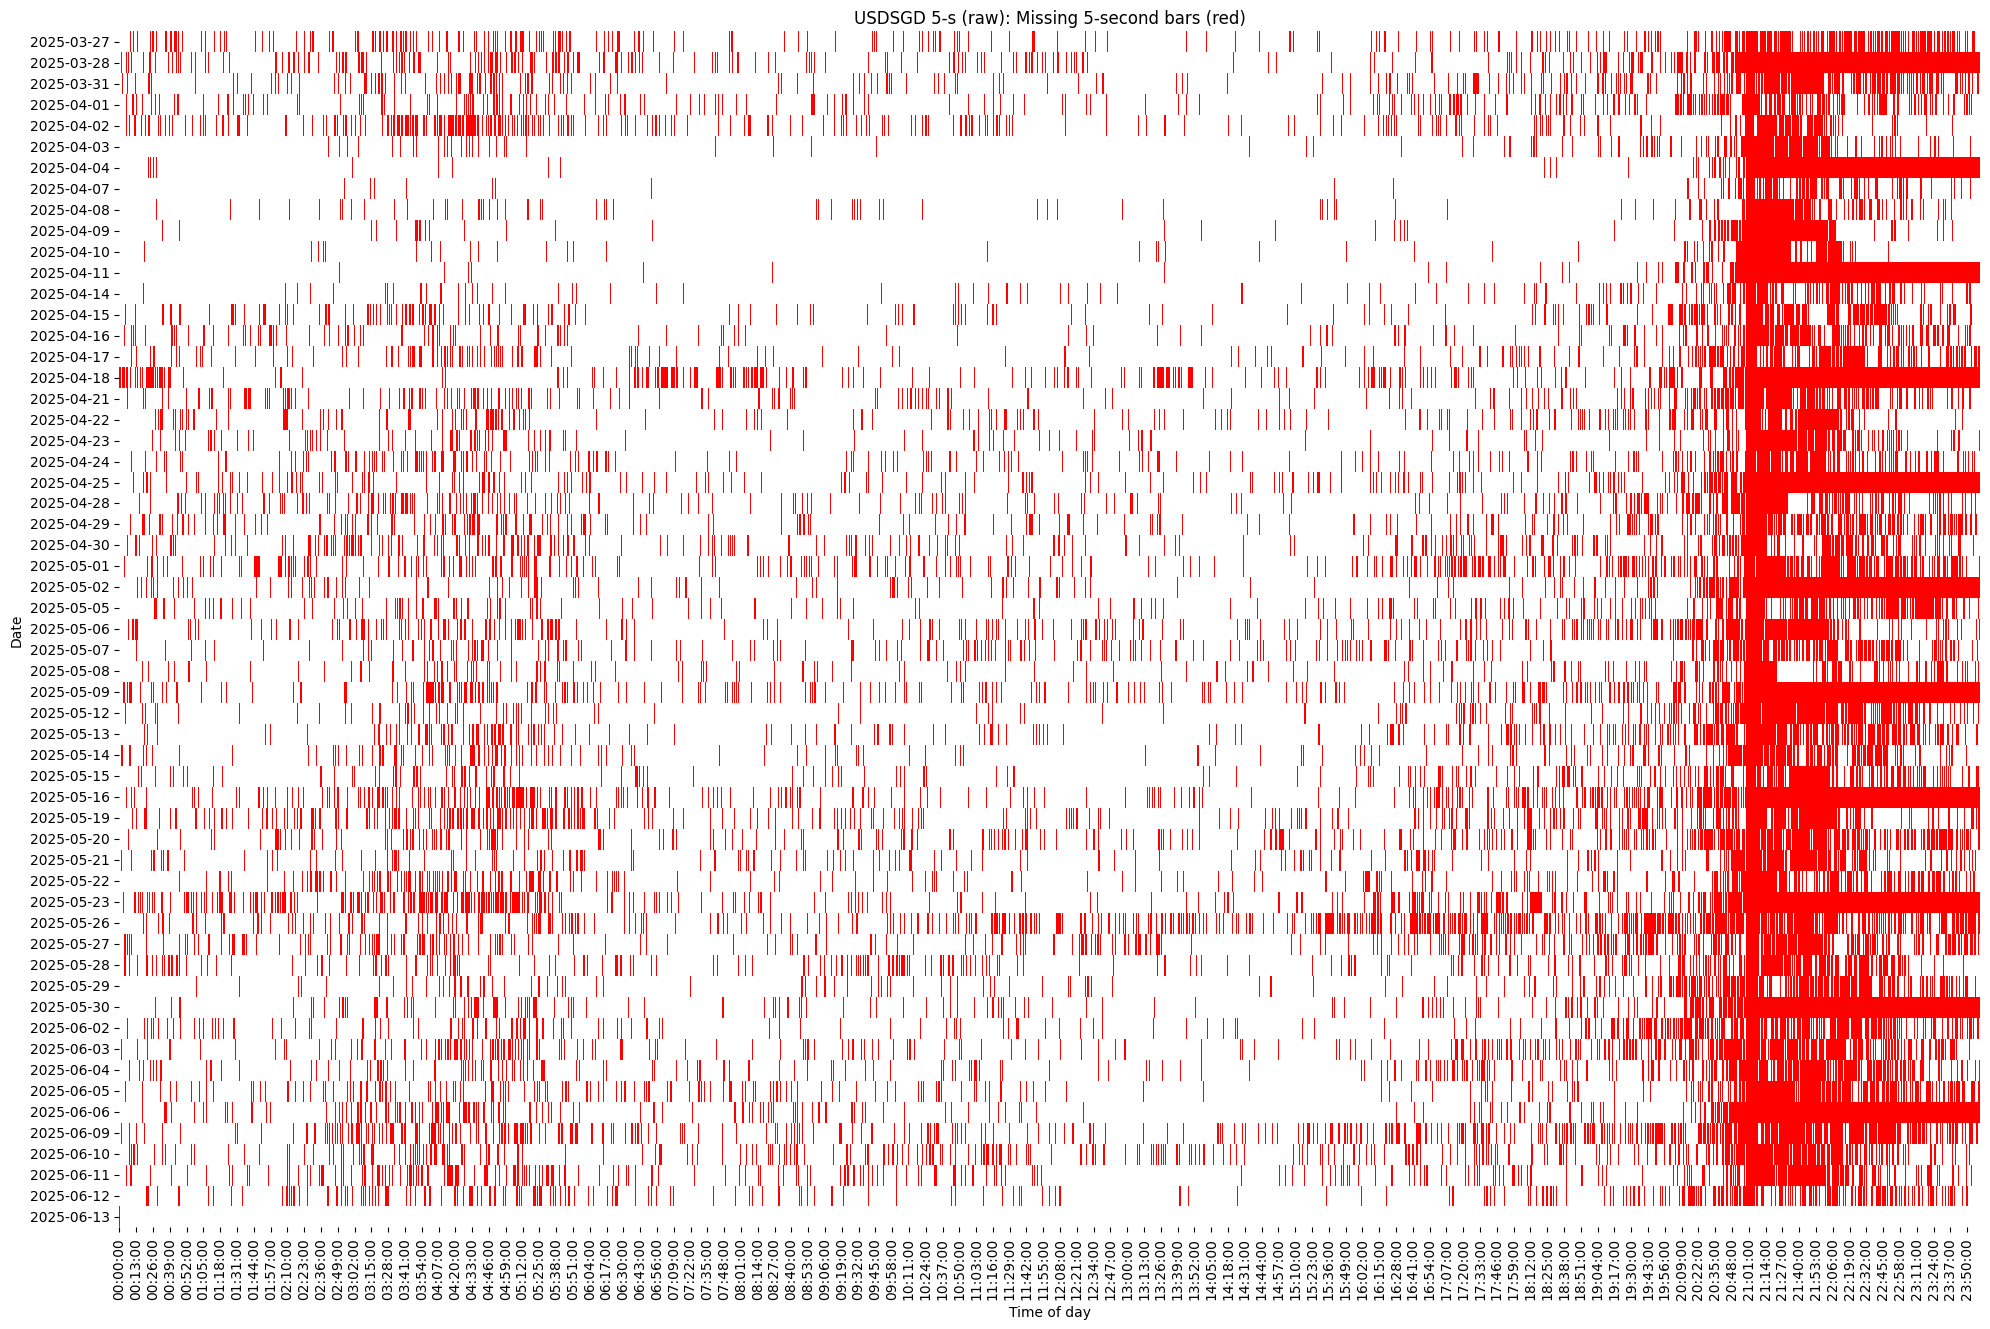

In [12]:
def visualise_missing_5s(df, title='EURUSD (5s data)'):


    start = df.index.min().floor('D') + pd.Timedelta(seconds=5)
    end   = df.index.max().ceil('D')
    full_idx = pd.date_range(start, end, freq='5s')

    trading_idx = full_idx[full_idx.dayofweek < 5]

    missing_mask = ~pd.Series(trading_idx).isin(df.index)
    missing_ser  = pd.Series(missing_mask.values, index=trading_idx, name='missing')

    miss_df = (missing_ser.astype(int)
                         .to_frame()
                         .assign(date=lambda x: x.index.date,
                                 time=lambda x: x.index.time))

    miss_piv = miss_df.pivot_table(index='date', columns='time',
                                   values='missing', aggfunc='max').fillna(0)

    plt.figure(figsize=(20, 0.20 * len(miss_piv) + 2))
    sns.heatmap(miss_piv,
                cmap=['white', 'red'],
                cbar=False,
                linewidths=.0)
    plt.title(f'{title}: Missing 5-second bars (red)')
    plt.xlabel('Time of day')
    plt.ylabel('Date')
    plt.tight_layout()
    plt.show()
visualise_missing_5s(euro_s5_clean, title='EURUSD 5-s (raw)')
visualise_missing_5s(sgd_s5_clean,  title='USDSGD 5-s (raw)')


In [1]:
#precleaning in one
from MFDFA_functions import get_moment_fluctuations_q, get_generalised_hurst, get_mf_spectrum
import numpy as np
from scipy.stats import norm, kurtosis, combine_pvalues
from scipy.stats import t as studt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from MFDFA_new import MFDFA
import pandas as pd
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/S5_EURUSD_mid.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/S5_USDSGD_mid.parquet")
euro_d = pd.read_excel("/Users/alexvillamartin/Documents/MSc Diss/Code/Daily EURUSD spot.xlsx")
sgd_d = pd.read_excel("/Users/alexvillamartin/Documents/MSc Diss/Code/Daily USDSGD spot.xlsx")
euro_d.set_index("Date", inplace=True)
sgd_d.set_index("Date", inplace=True)

euro_d.rename(columns = {
    "Spot": "Mid"
}, inplace = True)
sgd_d.rename(columns = {
    "Spot": "Mid"
}, inplace = True)
length_s5 = len(euro_s5)
euro_s5 = euro_s5.iloc[int(length_s5/2):]
sgd_s5 = sgd_s5.iloc[int(length_s5/2):]
def get_log_returns(df):

    df['Log_r'] = np.log(pd.to_numeric(df['Mid'])).diff()
    df = df.dropna()
    return df
euro_s5 = get_log_returns(euro_s5)
sgd_s5 = get_log_returns(sgd_s5)
euro_d = get_log_returns(euro_d)
sgd_d = get_log_returns(sgd_d)

def remove_first_day_and_last(df):
    df_copy = df.copy()

    first_date = df_copy.index.date[0] 
    last_date = df_copy.index.date[-1]

    mask = (df_copy.index.date != first_date) & (df_copy.index.date != last_date)

    return df_copy[mask]

euro_s5_clean = remove_first_day_and_last(euro_s5)
sgd_s5_clean = remove_first_day_and_last(sgd_s5)

def check_complete_5s_intervals(df):
    '''
    This function overlays a full 5 second index onto data and ffils missing values to ensure all intervals in 
    specified hours are there. 
    '''

    df_copy = df.copy()
    
    start_date = df_copy.index.min().floor('D') + pd.Timedelta(hours = 0, minutes=0, seconds=5)
    end_date = df_copy.index.max().ceil('D')
    full_index = pd.date_range(start=start_date, end=end_date, freq='5s')

    weekday_index = full_index.dayofweek < 5
    
    trading_index = full_index[weekday_index]
    
    df_complete = df_copy.reindex(trading_index).ffill()
    
    return df_complete

euro_s5_clean = check_complete_5s_intervals(euro_s5_clean)
sgd_s5_clean = check_complete_5s_intervals(sgd_s5_clean)


n_days = len(pd.Series(sgd_s5_clean.index.date).unique())-1 # as last day has next days date for final interval
K = len(sgd_s5_clean) // n_days # number of points per day
def get_trend(Y, K):

    n_days = len(Y) // K       

    trend = Y.reshape(n_days, K).mean(axis=0)

    return trend

def get_detrended_series(trend, Y, K, small = True):

    n_days = len(Y) // K

    if small:
        X = Y.reshape(n_days, K) - trend
    else:
        X = Y.reshape(n_days, K) / trend

    return X.ravel()

eur_s5_log_rs_clean = np.array(euro_s5_clean["Log_r"])
sgd_s5_log_rs_clean = np.array(sgd_s5_clean["Log_r"])
eur_trend = get_trend(eur_s5_log_rs_clean, K)
sgd_trend = get_trend(sgd_s5_log_rs_clean, K)
euro_s5_clean["Log_r_detrended"] = get_detrended_series(eur_trend, eur_s5_log_rs_clean, K)
sgd_s5_clean["Log_r_detrended"] = get_detrended_series(sgd_trend, sgd_s5_log_rs_clean, K)

In [7]:
qs = np.arange(-6, 7,1)
versions = ["Raw", "Abs", "Squared"]
datas = [euro_d, sgd_d, euro_s5_clean, sgd_s5_clean]
types = ["EURUSD Daily", "USDSGD Daily", "EURUSD S5 Detrend", "USDSGD S5 Detrend"]

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_30725/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


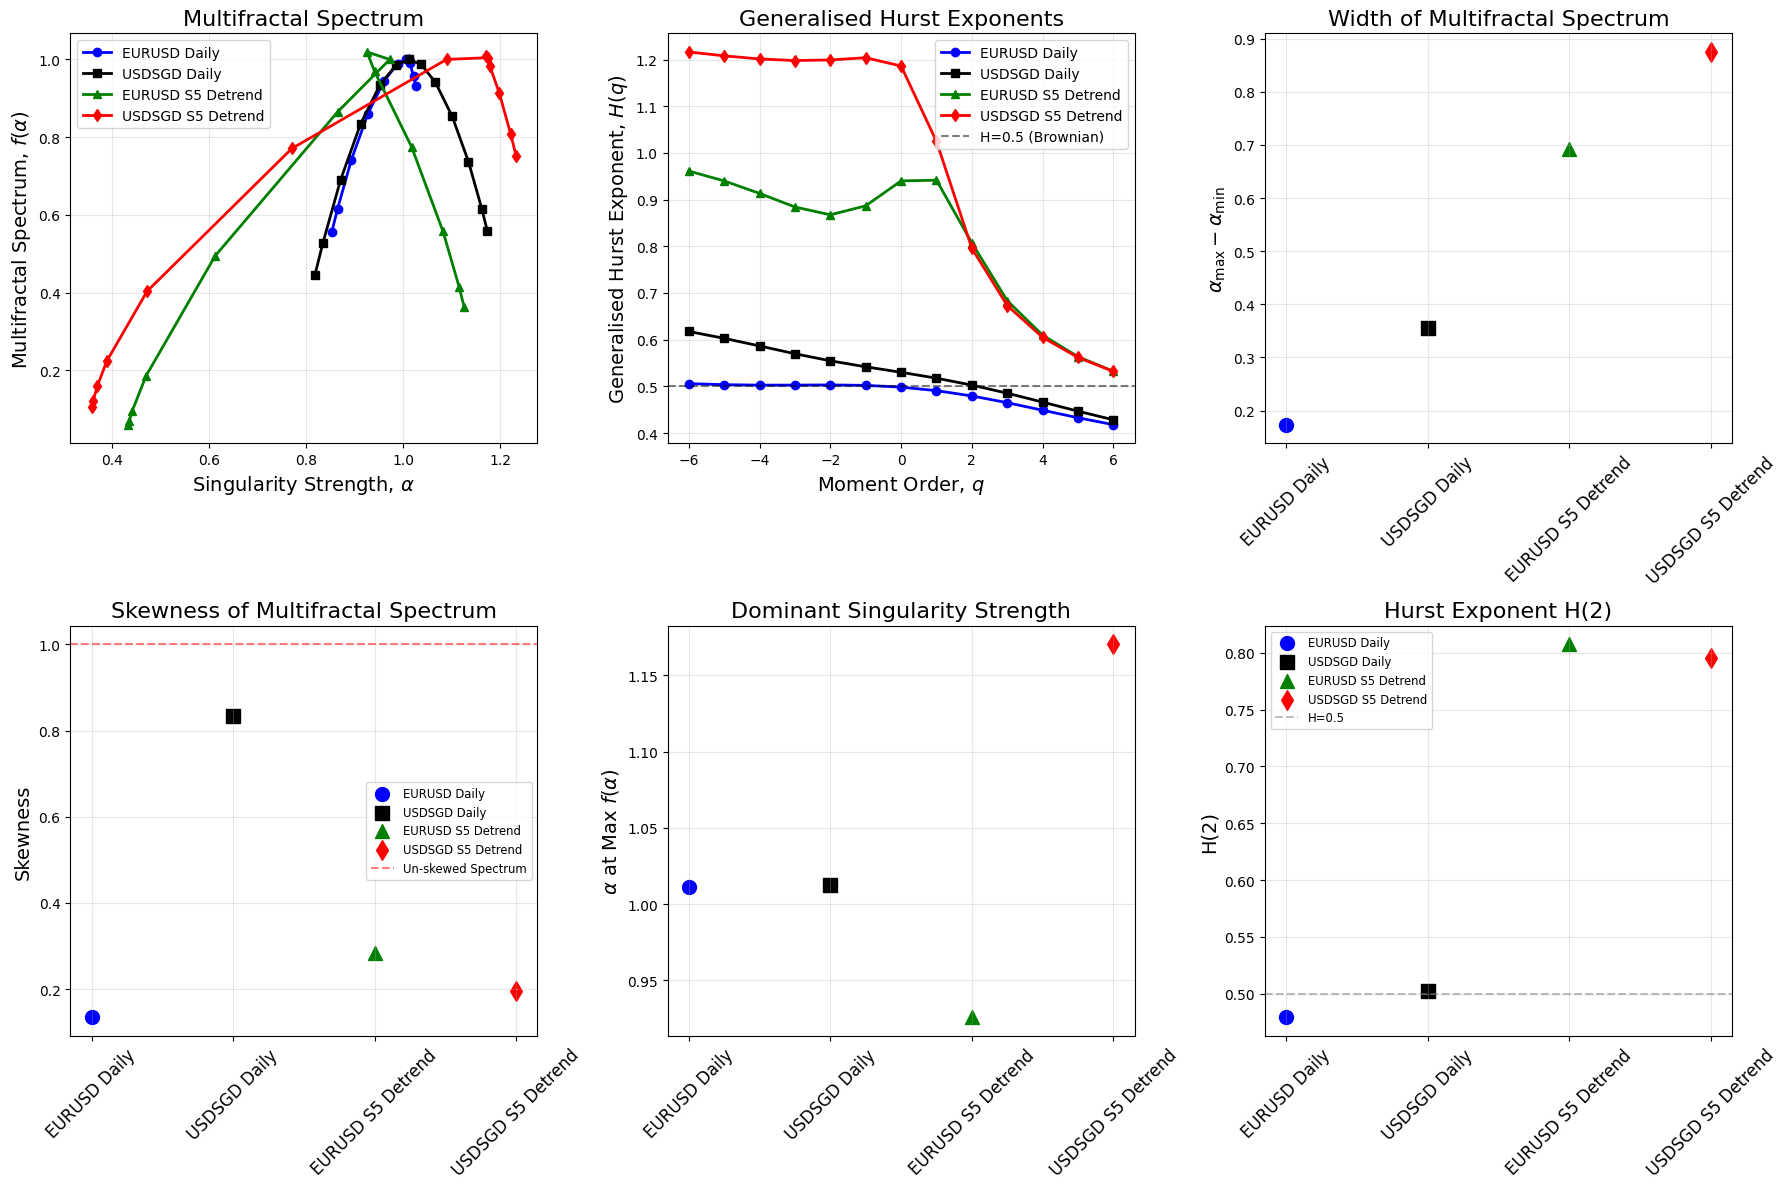

In [5]:
hs_1 = np.zeros((len(types), len(qs)))
alphas_1 = np.zeros((len(types), len(qs)))
f_alphas_1 = np.zeros((len(types), len(qs)))
F_qs = []
sss = []
datas = [euro_d, sgd_d, euro_s5_clean, sgd_s5_clean]

for i in range(len(types)):
    if i <2:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _ , F_qs_i, ss_i = get_all_spectrum(datas[i], versions[0], qs=qs, s_min = 10, detrend=False)
    else:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _, F_qs_i, ss_i = get_all_spectrum(datas[i], versions[0], qs=qs, s_min = 1000, m=1, detrend=True)

    F_qs.append(F_qs_i)
    sss.append(ss_i)

plot_multifractal_analysis(
    alphas_list=alphas_1,
    f_alphas_list=f_alphas_1, 
    hs_list=hs_1,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_raw_r_full_DETREND__s5_data"
    )

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_30725/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


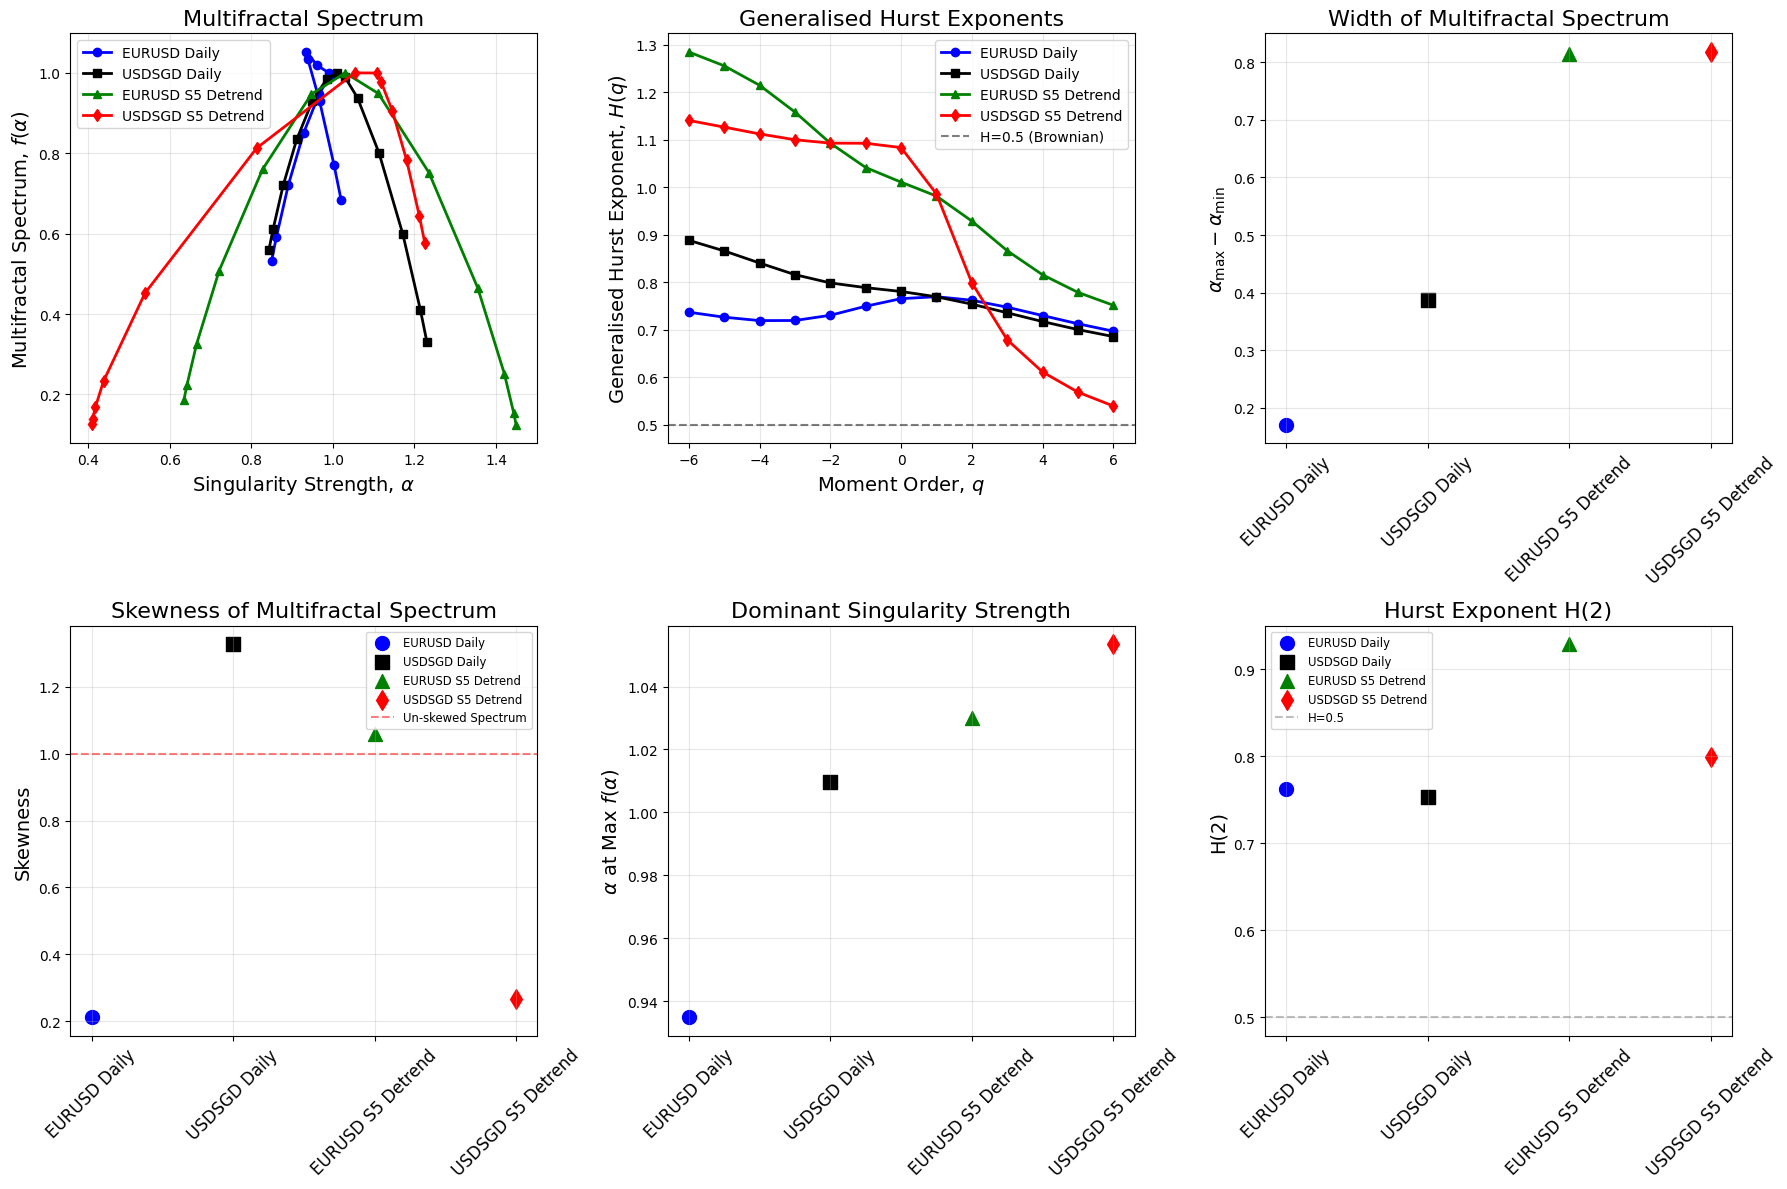

In [8]:
hs_1 = np.zeros((len(types), len(qs)))
alphas_1 = np.zeros((len(types), len(qs)))
f_alphas_1 = np.zeros((len(types), len(qs)))
F_qs = []
sss = []
datas = [euro_d, sgd_d, euro_s5_clean, sgd_s5_clean]

for i in range(len(types)):
    if i <2:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _ , F_qs_i, ss_i = get_all_spectrum(datas[i], versions[1], qs=qs, s_min = 10, detrend=False)
    else:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _, F_qs_i, ss_i = get_all_spectrum(datas[i], versions[1], qs=qs, s_min = 1000, m=1, detrend=True)

    F_qs.append(F_qs_i)
    sss.append(ss_i)

plot_multifractal_analysis(
    alphas_list=alphas_1,
    f_alphas_list=f_alphas_1, 
    hs_list=hs_1,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_abs_r_full_DETREND__s5_data"
    )

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_30725/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


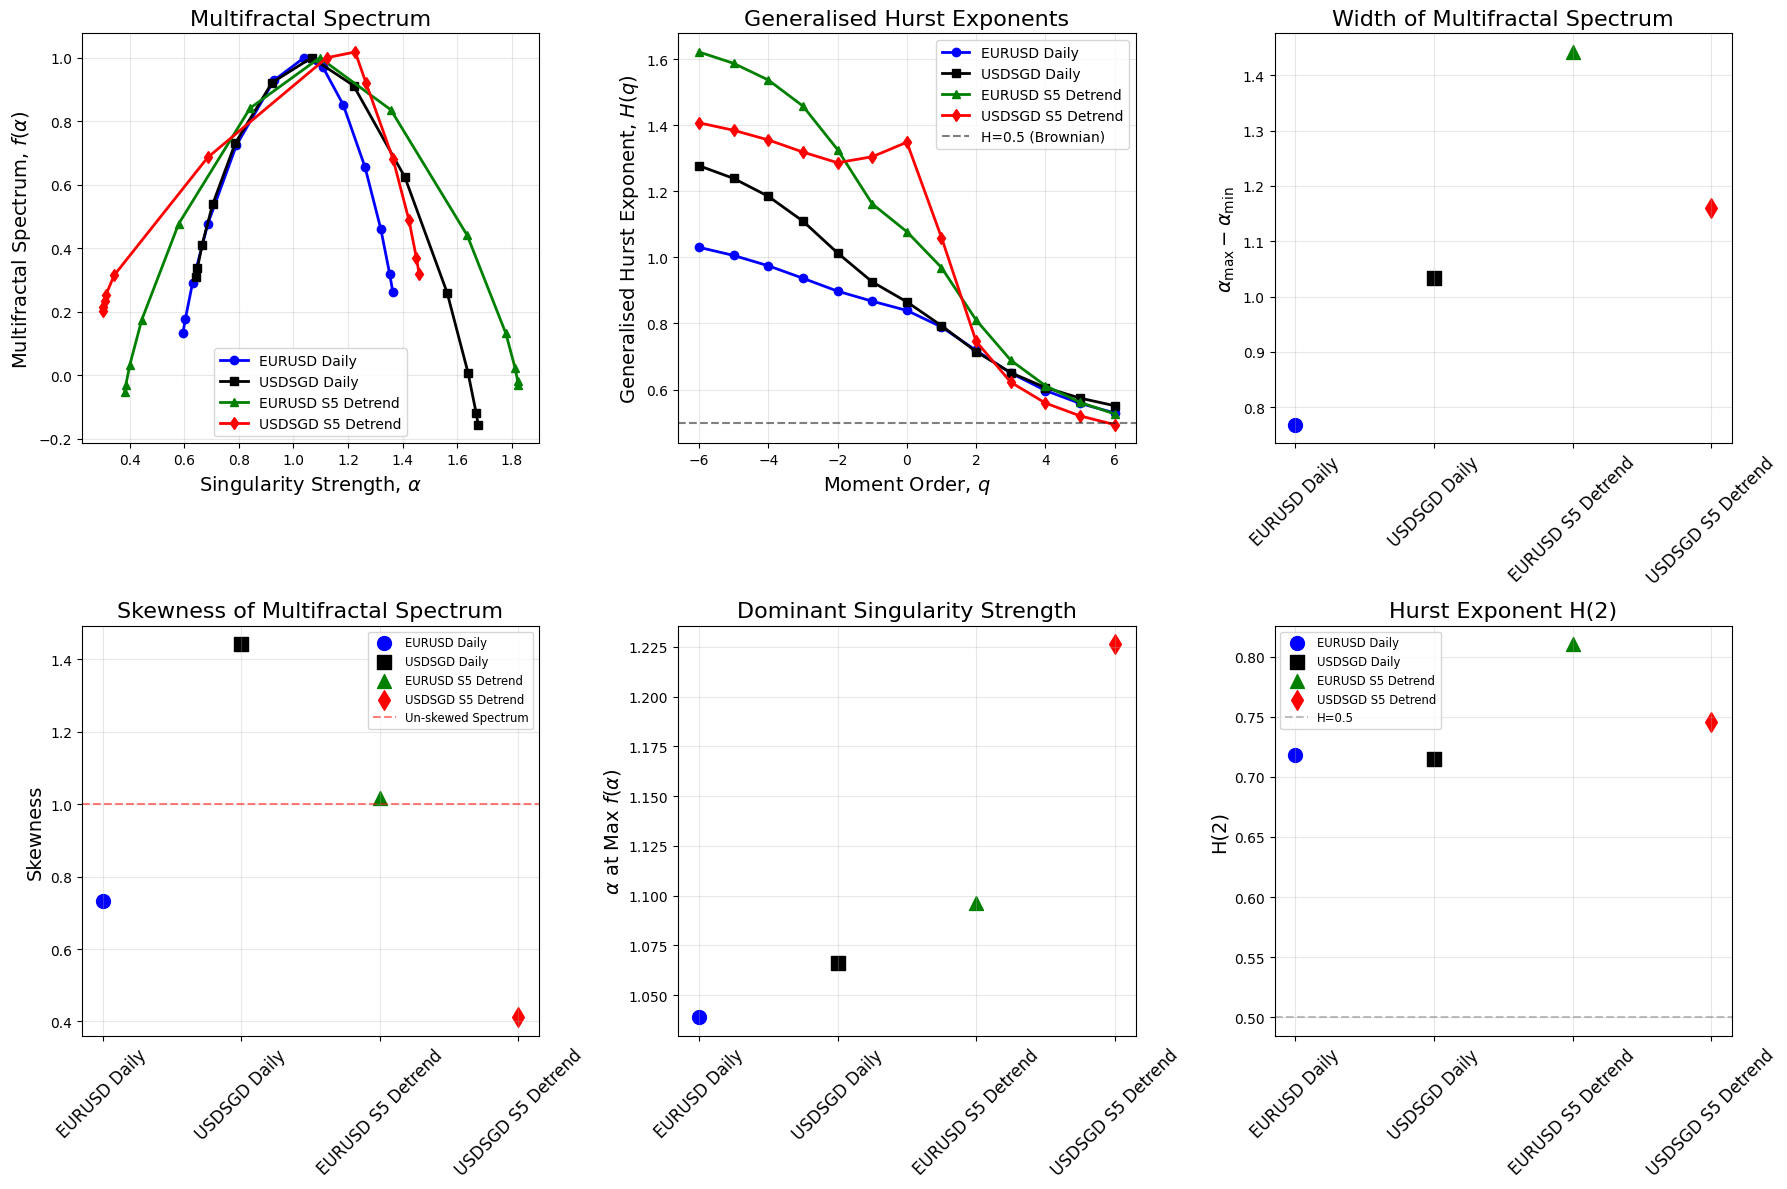

In [9]:
hs_1 = np.zeros((len(types), len(qs)))
alphas_1 = np.zeros((len(types), len(qs)))
f_alphas_1 = np.zeros((len(types), len(qs)))
F_qs = []
sss = []
datas = [euro_d, sgd_d, euro_s5_clean, sgd_s5_clean]

for i in range(len(types)):
    if i <2:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _ , F_qs_i, ss_i = get_all_spectrum(datas[i], versions[2], qs=qs, s_min = 10, detrend=False)
    else:
        hs_1[i, :], alphas_1[i, :], f_alphas_1[i, :], _, F_qs_i, ss_i = get_all_spectrum(datas[i], versions[2], qs=qs, s_min = 1000, m=1, detrend=True)

    F_qs.append(F_qs_i)
    sss.append(ss_i)

plot_multifractal_analysis(
    alphas_list=alphas_1,
    f_alphas_list=f_alphas_1, 
    hs_list=hs_1,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_squared_r_full_DETREND__s5_data"
    )

# Sources of MF

We will use detrended trading hour versions as this seems most consistent. This is normal daily data and then Log_r_detrended for clean datasets.

In [3]:
qs = np.arange(-6, 7,1)
versions = ["Raw", "Squared"]
datas = [euro_d, sgd_d, euro_s5_clean, sgd_s5_clean]
types = ["EURUSD Daily", "USDSGD Daily", "EURUSD S5 Detrended", "USDSGD S5 Detrended"]

In [6]:
hs_detrend_raw = np.zeros((len(types), len(qs)))
alphas_detrend_raw = np.zeros((len(types), len(qs)))
f_alphas_detrend_raw = np.zeros((len(types), len(qs)))

for i in range(len(types)):
    if i <2:
        hs_detrend_raw[i, :], alphas_detrend_raw[i, :], f_alphas_detrend_raw[i, :], _ , _, _ = get_all_spectrum(datas[i], versions[0], qs=qs, s_min = 10, detrend=False)
    else:
        hs_detrend_raw[i, :], alphas_detrend_raw[i, :], f_alphas_detrend_raw[i, :], _, _, _ = get_all_spectrum(datas[i], versions[0], qs=qs, s_min = 1000, m=1, detrend=True)

hs_detrended_squared = np.zeros((len(types), len(qs)))
alphas_detrended_squared = np.zeros((len(types), len(qs)))
f_alphas_detrended_squared = np.zeros((len(types), len(qs)))
for i in range(len(types)):
    if i <2:
        hs_detrended_squared[i, :], alphas_detrended_squared[i, :], f_alphas_detrended_squared[i, :], _ , _, _ = get_all_spectrum(datas[i], versions[1], qs=qs, s_min = 10, detrend=False)
    else:
        hs_detrended_squared[i, :], alphas_detrended_squared[i, :], f_alphas_detrended_squared[i, :], _, _, _ = get_all_spectrum(datas[i], versions[1], qs=qs, s_min = 1000, m=1, detrend=True)


/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_32865/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


Shuffle data too.

In [29]:
euro_s5_clean_log_r_detrend_shuff = euro_s5_clean[["Log_r_detrended"]].sample(frac=1, replace=False, random_state = 22 ).reset_index(drop=True)
sgd_s5_clean_log_r_detrend_shuff = sgd_s5_clean[["Log_r_detrended"]].sample(frac=1, replace=False, random_state = 2 ).reset_index(drop=True)
euro_d_log_r = euro_d[["Log_r"]].sample(frac=1, replace=False, random_state = 2 ).reset_index(drop=True)
sgd_d_log_r = sgd_d[["Log_r"]].sample(frac=1, replace=False, random_state = 2 ).reset_index(drop=True)

In [30]:
datas = [euro_d_log_r, sgd_d_log_r, euro_s5_clean_log_r_detrend_shuff, sgd_s5_clean_log_r_detrend_shuff]
types = ["EURUSD Daily Shuff", "USDSGD Daily Shuff", "EURUSD S5 Detrended Shuff", "USDSGD S5 Detrended Shuff"]

hs_detrend_raw_shuff = np.zeros((len(types), len(qs)))
alphas_detrend_raw_shuff = np.zeros((len(types), len(qs)))
f_alphas_detrend_raw_shuff = np.zeros((len(types), len(qs)))

for i in range(len(types)):
    if i <2:
        hs_detrend_raw_shuff[i, :], alphas_detrend_raw_shuff[i, :], f_alphas_detrend_raw_shuff[i, :], _ , _, _ = get_all_spectrum(datas[i], versions[0], qs=qs, s_min = 10, detrend=False)
    else:
        hs_detrend_raw_shuff[i, :], alphas_detrend_raw_shuff[i, :], f_alphas_detrend_raw_shuff[i, :], _, _, _ = get_all_spectrum(datas[i], versions[0], qs=qs, s_min = 1000, m=1, detrend=True)

hs_detrended_squared_shuff = np.zeros((len(types), len(qs)))
alphas_detrended_squared_shuff = np.zeros((len(types), len(qs)))
f_alphas_detrended_squared_shuff = np.zeros((len(types), len(qs)))
for i in range(len(types)):
    if i <2:
        hs_detrended_squared_shuff[i, :], alphas_detrended_squared_shuff[i, :], f_alphas_detrended_squared_shuff[i, :], _ , _, _ = get_all_spectrum(datas[i], versions[1], qs=qs, s_min = 10, detrend=False)
    else:
        hs_detrended_squared_shuff[i, :], alphas_detrended_squared_shuff[i, :], f_alphas_detrended_squared_shuff[i, :], _, _, _ = get_all_spectrum(datas[i], versions[1], qs=qs, s_min = 1000, m=1, detrend=True)


/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_32865/509132421.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)


Plot shuffled data.

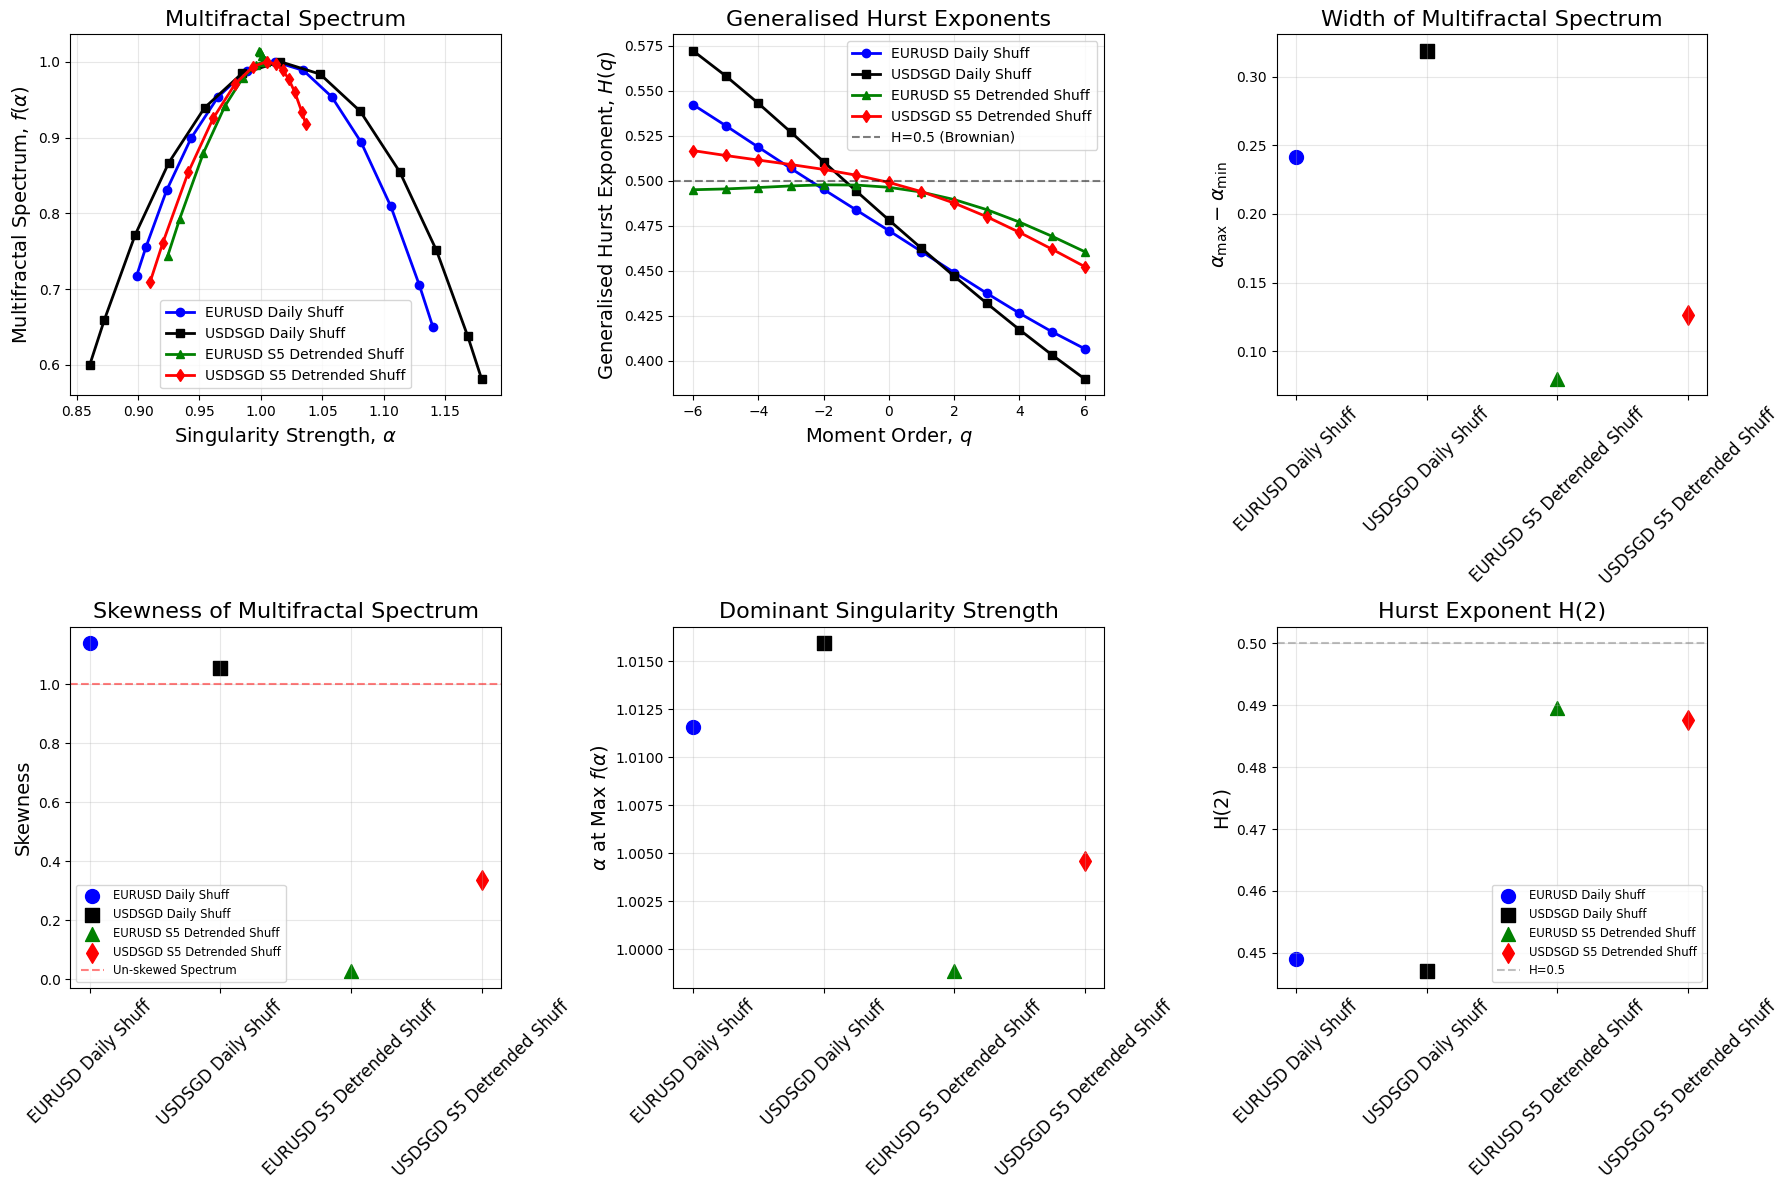

In [31]:
plot_multifractal_analysis(
    alphas_list=alphas_detrend_raw_shuff,
    f_alphas_list=f_alphas_detrend_raw_shuff, 
    hs_list=hs_detrend_raw_shuff,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_raw_shuffled_trading_hours"
    )

Green doesnt seem right but shuffled is random so difficult to comment on. One above has different random state and looks to the eye much better. 

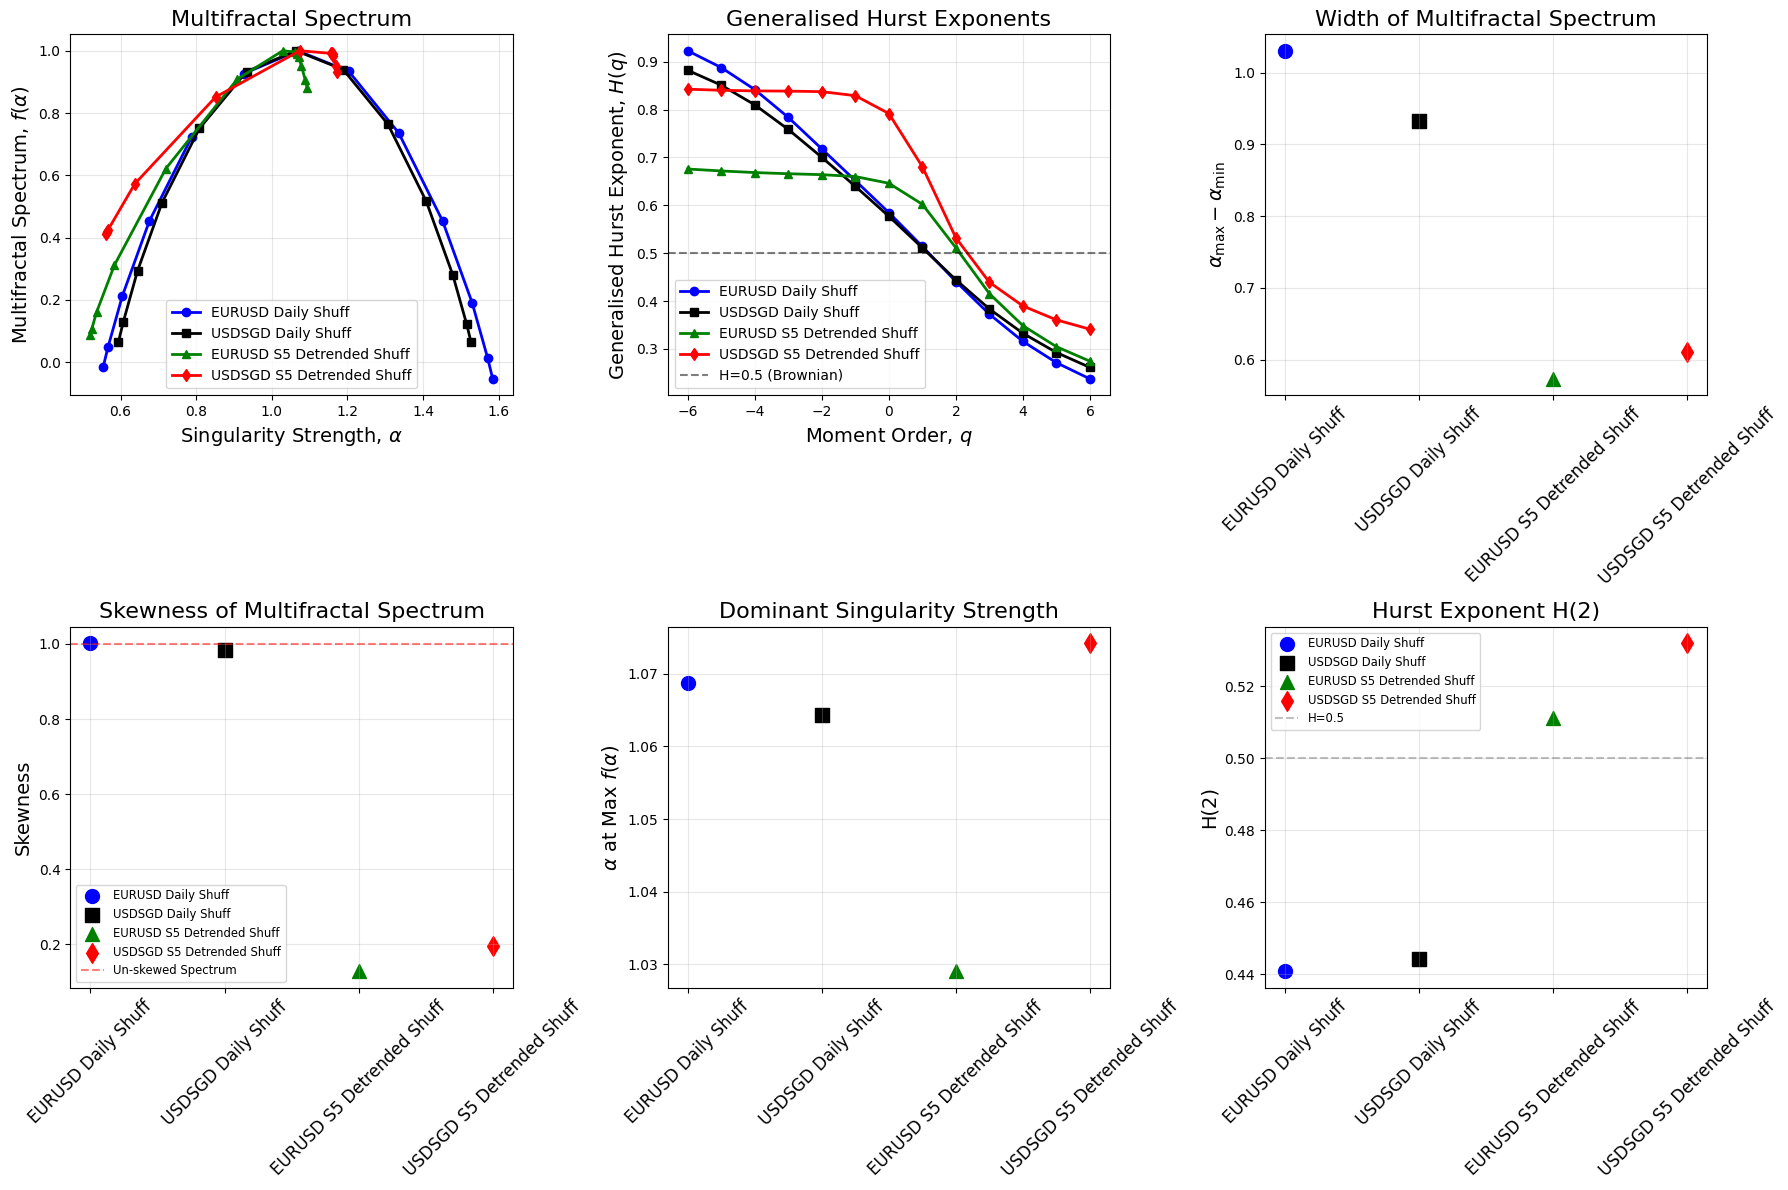

In [28]:
plot_multifractal_analysis(
    alphas_list=alphas_detrended_squared_shuff,
    f_alphas_list=f_alphas_detrended_squared_shuff, 
    hs_list=hs_detrended_squared_shuff,
    data_names=types,
    qs=qs,
    save_path="/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_squared_shuffled_trading_hours"
    )

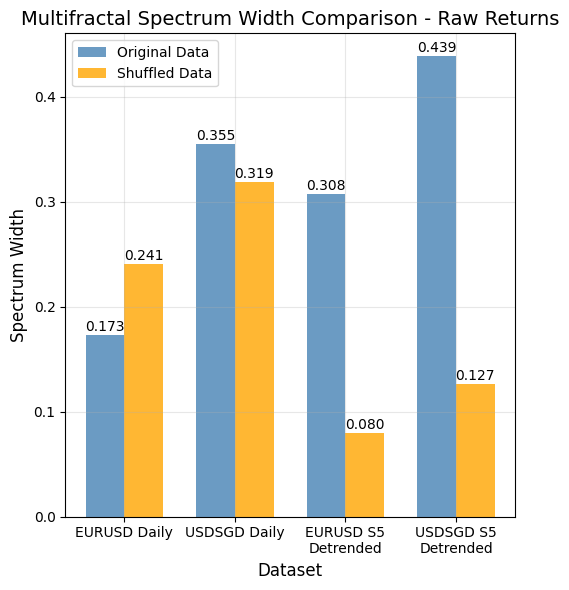

In [38]:
data_names_original = ["EURUSD Daily", "USDSGD Daily", "EURUSD S5 Detrended", "USDSGD S5 Detrended"]
data_names_shuffled = ["EURUSD Daily Shuff", "USDSGD Daily Shuff", "EURUSD S5 Detrended Shuff", "USDSGD S5 Detrended Shuff"]

widths_raw_original = []
widths_raw_shuffled = []

for i in range(len(data_names_original)):
    alpha_width_orig = np.max(alphas_detrend_raw[i, :]) - np.min(alphas_detrend_raw[i, :])
    widths_raw_original.append(alpha_width_orig)
    
    alpha_width_shuff = np.max(alphas_detrend_raw_shuff[i, :]) - np.min(alphas_detrend_raw_shuff[i, :])
    widths_raw_shuffled.append(alpha_width_shuff)

plt.figure(figsize=(10, 6))

x_pos = np.arange(len(data_names_original))
width = 0.35

plt.subplot(1, 2, 1)
bars1 = plt.bar(x_pos - width/2, widths_raw_original, width, label='Original Data', alpha=0.8, color='steelblue')
bars2 = plt.bar(x_pos + width/2, widths_raw_shuffled, width, label='Shuffled Data', alpha=0.8, color='orange')

plt.xlabel('Dataset', fontsize=12)
plt.ylabel(r'Spectrum Width', fontsize=12)
plt.title('Multifractal Spectrum Width Comparison - Raw Returns', fontsize=14)
plt.xticks(x_pos, [name.replace(' Detrended', '\nDetrended') for name in data_names_original], rotation=0, ha='center')
plt.legend()
plt.grid(True, alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_width_raw_trading_hours.png")
plt.show()

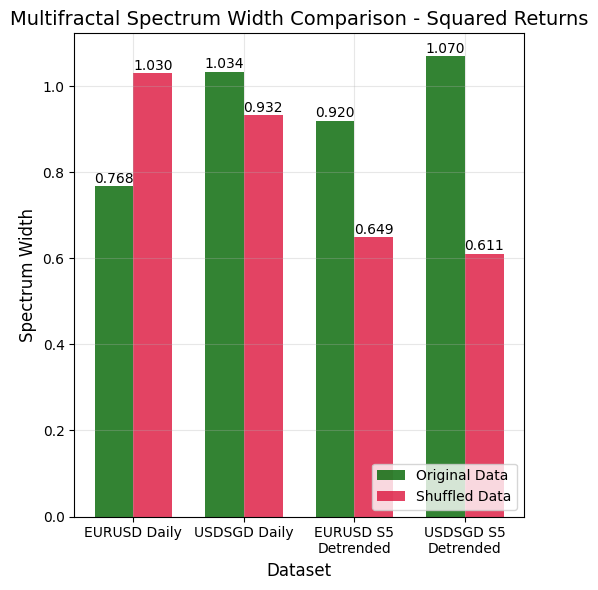

In [40]:
widths_squared_original = []
widths_squared_shuffled = []

for i in range(len(data_names_original)):
    alpha_width_orig = np.max(alphas_detrended_squared[i, :]) - np.min(alphas_detrended_squared[i, :])
    widths_squared_original.append(alpha_width_orig)
    
    alpha_width_shuff = np.max(alphas_detrended_squared_shuff[i, :]) - np.min(alphas_detrended_squared_shuff[i, :])
    widths_squared_shuffled.append(alpha_width_shuff)

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
bars1 = plt.bar(x_pos - width/2, widths_squared_original, width, label='Original Data', alpha=0.8, color='darkgreen')
bars2 = plt.bar(x_pos + width/2, widths_squared_shuffled, width, label='Shuffled Data', alpha=0.8, color='crimson')

plt.xlabel('Dataset', fontsize=12)
plt.ylabel(r'Spectrum Width', fontsize=12)
plt.title('Multifractal Spectrum Width Comparison - Squared Returns', fontsize=14)
plt.xticks(x_pos, [name.replace(' Detrended', '\nDetrended') for name in data_names_original], rotation=0, ha='center')
plt.legend(loc = 'lower right')
plt.grid(True, alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("/Users/alexvillamartin/Documents/MSc Diss/Plots/mf_spectrum_width_squared_trading_hours.png")
plt.show()